**bold text**#  Cardiovascular · Endocrine · Mental Health
### Clinical Database & Analytics System — CMS Medicare Open Data

---

**Focus Areas:**

| Category | Conditions Tracked |
|---|---|
| ❤️ **Cardiovascular** | Hypertension, Heart Failure, Ischemic Heart Disease, Atrial Fibrillation, Acute MI, Stroke/TIA |
| 🩺 **Endocrine** | Type 2 Diabetes, Hyperlipidemia, Obesity, Hypothyroidism |
| 🧠 **Mental Health** | Major Depression, Anxiety, Bipolar Disorder, Schizophrenia |

**Why these three together?** CMS research shows these categories are deeply co-morbid:
- 60% of diabetic Medicare patients also have hypertension
- Depression affects 30%+ of heart failure patients
- Obesity drives both cardiovascular risk and mental health outcomes

**Data Sources (all free, no login):**
- CMS `data.cms.gov` — Medicare Chronic Conditions (18 conditions, all US states)
- NLM RxNorm `rxnav.nlm.nih.gov` — Drug name API
- Listed in SLU Cross-Disciplinary Health Resources guide

**SQL Concepts:** 14 tables · 4 triggers · 2 events · 2 stored procedures · 1 stored function ·
3 views · CTEs · Recursive CTEs · Window Functions · SCD Type 2 · Audit Trail · Full-Text Search

**Tech Stack:** MySQL 8 · mysql-connector-python · SQLAlchemy · requests · pandas · matplotlib · seaborn


## Section 1 — Environment Bootstrap

In [1]:
# ── 1a. Install MySQL server ──────────────────────────────────────────────
import subprocess, sys, os, time

result = subprocess.run(["apt-get","install","-y","-qq","mysql-server"],
                        capture_output=True, text=True)
print("MySQL server installed ✓" if result.returncode == 0 else result.stderr[:200])


MySQL server installed ✓


In [2]:
# ── 1b. Bootstrap MySQL root credentials ─────────────────────────────────
os.system("service mysql stop")
os.makedirs("/var/run/mysqld", exist_ok=True)
os.system("chown mysql:mysql /var/run/mysqld")
os.system("mysqld --skip-grant-tables --skip-networking &")
time.sleep(6)

sql_cmd = "FLUSH PRIVILEGES; ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'CardioMH@2024';"
os.system(f'mysql -e "{sql_cmd}"')
os.system("service mysql restart")
time.sleep(3)
print("MySQL bootstrapped ✓  |  password set ✓")


MySQL bootstrapped ✓  |  password set ✓


In [3]:
# ── 1c. Install Python packages ───────────────────────────────────────────
deps = ["mysql-connector-python","sqlalchemy","pymysql","pandas",
        "matplotlib","seaborn","tabulate","numpy","requests","faker"]
subprocess.run([sys.executable,"-m","pip","install","-q"]+deps, capture_output=True)
print("Packages ready:", ", ".join(deps))


Packages ready: mysql-connector-python, sqlalchemy, pymysql, pandas, matplotlib, seaborn, tabulate, numpy, requests, faker


In [4]:
# ── 1d. Database connection ───────────────────────────────────────────────
import mysql.connector, pandas as pd, numpy as np
import requests, json, hashlib, random
import matplotlib.pyplot as plt, seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from datetime import date, timedelta
from faker import Faker

DB   = "cardio_endo_mh_db"
fake = Faker(['en_US'])
random.seed(42); np.random.seed(42)

boot = mysql.connector.connect(host="localhost",user="root",password="CardioMH@2024")
boot.cursor().execute(
    f"CREATE DATABASE IF NOT EXISTS {DB} CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci"
)
boot.close()

conn   = mysql.connector.connect(host="localhost",user="root",
                                  password="CardioMH@2024",database=DB)
cursor = conn.cursor()

db_url = URL.create(drivername="mysql+pymysql",username="root",
                    password="CardioMH@2024",host="localhost",database=DB)
engine = create_engine(db_url)

def sql(query):  return pd.read_sql(query, engine)
def run(query, params=None): cursor.execute(query, params or ())

print(f"Connected to '{DB}' ✓")
print("Focus: Cardiovascular · Endocrine · Mental Health")


Connected to 'cardio_endo_mh_db' ✓
Focus: Cardiovascular · Endocrine · Mental Health


## Section 2 — Schema Design
*14 tables purpose-built for Cardiovascular, Endocrine & Mental Health tracking*

**Schema overview:**
```
Patients            — demographic + insurance (Medicare-age population)
Physicians          — cardiologists, endocrinologists, psychiatrists (self-referencing)
Diagnoses_Lookup    — ICD-10 codes for 3 focus categories only
Medications_Lookup  — cardiac, diabetic, psychiatric drug formulary
Allergies           — drug/food allergies (critical for psych + cardiac meds)
PatientDiagnoses    — diagnosis events with SCD Type 2 versioning
Prescriptions       — medication orders with adherence tracking
Procedures          — cardiac caths, glucose monitoring, therapy sessions
LabResults          — HbA1c, lipids, BNP, PHQ-9 scores, troponin
VitalSigns          — BP, HR, BMI, SpO2 (computed generated column)
ClinicalNotes       — SOAP notes with full-text search
PatientPhysician    — bridge: many patients ↔ many physicians
AuditLog            — immutable change trail
DeletedRecords      — soft-delete archive
```

In [5]:
# ── Drop all tables cleanly (FK-safe order) ───────────────────────────────
drop_order = [
    "AuditLog","DeletedRecords","PatientPhysician","ClinicalNotes",
    "VitalSigns","LabResults","Procedures","Prescriptions",
    "PatientDiagnoses","Allergies","Medications_Lookup",
    "Diagnoses_Lookup","Physicians","Patients"
]
run("SET FOREIGN_KEY_CHECKS = 0")
for t in drop_order:
    run(f"DROP TABLE IF EXISTS {t}")
run("SET FOREIGN_KEY_CHECKS = 1")
conn.commit()
print("Tables cleared ✓")


Tables cleared ✓


In [6]:
# ── 2a. Patients ──────────────────────────────────────────────────────────
run("""
CREATE TABLE Patients (
    id              INT AUTO_INCREMENT PRIMARY KEY,
    mrn             VARCHAR(12) UNIQUE NOT NULL,
    full_name       VARCHAR(120) NOT NULL,
    dob             DATE NOT NULL,
    gender          ENUM('Male','Female','Other') NOT NULL,
    blood_type      ENUM('A+','A-','B+','B-','AB+','AB-','O+','O-'),
    email           VARCHAR(180) UNIQUE,
    phone           VARCHAR(20),
    city            VARCHAR(80),
    state           VARCHAR(2),
    insurance_id    VARCHAR(30),
    ssn_encrypted   VARBINARY(255),                     -- #85 AES-encrypted
    smoker          TINYINT(1) DEFAULT 0,               -- cardiovascular risk factor
    family_hx_cvd   TINYINT(1) DEFAULT 0,               -- family history CVD
    family_hx_dm    TINYINT(1) DEFAULT 0,               -- family history diabetes
    family_hx_mh    TINYINT(1) DEFAULT 0,               -- family history mental health
    is_active       TINYINT(1) DEFAULT 1,               -- #57 soft delete
    risk_tier       VARCHAR(20) DEFAULT 'Minimal',
    created_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP
)
""")

# ── 2b. Physicians (self-referencing supervisor hierarchy) ────────────────
run("""
CREATE TABLE Physicians (
    id            INT AUTO_INCREMENT PRIMARY KEY,
    full_name     VARCHAR(120) NOT NULL,
    specialty     VARCHAR(80),
    subspecialty  VARCHAR(80),                          -- e.g. Interventional Cardiology
    npi           VARCHAR(15) UNIQUE,
    email         VARCHAR(180),
    supervisor_id INT DEFAULT NULL,                     -- #55 self-referencing FK
    is_active     TINYINT(1) DEFAULT 1,
    FOREIGN KEY (supervisor_id) REFERENCES Physicians(id)
)
""")

# ── 2c. Diagnoses_Lookup — focused on 3 categories ────────────────────────
run("""
CREATE TABLE Diagnoses_Lookup (
    id                  INT AUTO_INCREMENT PRIMARY KEY,
    icd10_code          VARCHAR(10) UNIQUE NOT NULL,
    description         VARCHAR(200) NOT NULL,
    category            ENUM('Cardiovascular','Endocrine','Mental Health') NOT NULL,
    subcategory         VARCHAR(80),
    is_chronic          TINYINT(1) DEFAULT 0,
    cms_condition_name  VARCHAR(120),
    cms_prevalence_pct  DECIMAL(5,2)                   -- real CMS national prevalence
)
""")

# ── 2d. Medications_Lookup ────────────────────────────────────────────────
run("""
CREATE TABLE Medications_Lookup (
    id              INT AUTO_INCREMENT PRIMARY KEY,
    drug_name       VARCHAR(120) NOT NULL,
    generic_name    VARCHAR(120),
    drug_class      VARCHAR(80),
    category        ENUM('Cardiovascular','Endocrine','Mental Health','Other'),
    controlled      TINYINT(1) DEFAULT 0,
    max_dose_mg     DECIMAL(8,2),
    requires_monitoring TINYINT(1) DEFAULT 0           -- e.g. lithium, warfarin
)
""")

conn.commit()
print("Core lookup tables created ✓  (Patients, Physicians, Diagnoses_Lookup, Medications_Lookup)")


Core lookup tables created ✓  (Patients, Physicians, Diagnoses_Lookup, Medications_Lookup)


In [7]:
# ── 2e. Clinical event tables ─────────────────────────────────────────────
run("""CREATE TABLE IF NOT EXISTS Allergies (
    id           INT AUTO_INCREMENT PRIMARY KEY,
    patient_id   INT NOT NULL,
    allergen     VARCHAR(120) NOT NULL,
    reaction     VARCHAR(200),
    severity     ENUM('Mild','Moderate','Severe','Life-Threatening'),
    onset_date   DATE,
    is_active    TINYINT(1) DEFAULT 1,
    FOREIGN KEY (patient_id) REFERENCES Patients(id))""")

run("""CREATE TABLE IF NOT EXISTS PatientDiagnoses (
    id              INT AUTO_INCREMENT PRIMARY KEY,
    patient_id      INT NOT NULL,
    diagnosis_id    INT NOT NULL,
    physician_id    INT NOT NULL,
    diagnosed_date  DATE NOT NULL,
    resolved_date   DATE DEFAULT NULL,
    status          ENUM('Active','Resolved','Chronic','Monitoring') DEFAULT 'Active',
    severity        ENUM('Mild','Moderate','Severe','Critical'),
    notes           TEXT,
    version         INT DEFAULT 1,                      -- #60 SCD Type 2 version
    is_current      TINYINT(1) DEFAULT 1,
    FOREIGN KEY (patient_id)   REFERENCES Patients(id),
    FOREIGN KEY (diagnosis_id) REFERENCES Diagnoses_Lookup(id),
    FOREIGN KEY (physician_id) REFERENCES Physicians(id))""")

run("""CREATE TABLE IF NOT EXISTS Prescriptions (
    id              INT AUTO_INCREMENT PRIMARY KEY,
    patient_id      INT NOT NULL,
    medication_id   INT NOT NULL,
    physician_id    INT NOT NULL,
    prescribed_date DATE NOT NULL,
    start_date      DATE NOT NULL,
    end_date        DATE,
    dose_mg         DECIMAL(8,2) NOT NULL,
    frequency       VARCHAR(60),
    status          ENUM('Active','Completed','Discontinued','On Hold') DEFAULT 'Active',
    refills_left    INT DEFAULT 0,
    adherence_pct   DECIMAL(5,2),                      -- medication adherence score
    is_active       TINYINT(1) DEFAULT 1,
    FOREIGN KEY (patient_id)    REFERENCES Patients(id),
    FOREIGN KEY (medication_id) REFERENCES Medications_Lookup(id),
    FOREIGN KEY (physician_id)  REFERENCES Physicians(id))""")

run("""CREATE TABLE IF NOT EXISTS Procedures (
    id             INT AUTO_INCREMENT PRIMARY KEY,
    patient_id     INT NOT NULL,
    physician_id   INT NOT NULL,
    procedure_name VARCHAR(150) NOT NULL,
    cpt_code       VARCHAR(10),
    category       ENUM('Cardiovascular','Endocrine','Mental Health','Other'),
    procedure_date DATE NOT NULL,
    facility       VARCHAR(120),
    outcome        ENUM('Successful','Complications','Pending','Cancelled'),
    duration_mins  INT,
    cost_usd       DECIMAL(10,2),
    notes          TEXT,
    FOREIGN KEY (patient_id)   REFERENCES Patients(id),
    FOREIGN KEY (physician_id) REFERENCES Physicians(id))""")

conn.commit()
print("Clinical event tables created ✓")


Clinical event tables created ✓


In [8]:
# ── 2f. Lab results, vitals, notes, bridge, audit ─────────────────────────
run("""CREATE TABLE IF NOT EXISTS LabResults (
    id           INT AUTO_INCREMENT PRIMARY KEY,
    patient_id   INT NOT NULL,
    physician_id INT NOT NULL,
    test_name    VARCHAR(100) NOT NULL,
    test_date    DATE NOT NULL,
    result_value DECIMAL(10,3),
    unit         VARCHAR(30),
    ref_low      DECIMAL(10,3),
    ref_high     DECIMAL(10,3),
    flag         ENUM('Normal','Low','High','Critical') DEFAULT 'Normal',
    category     ENUM('Cardiovascular','Endocrine','Mental Health','General'),
    detail_json  JSON,                                  -- #96 JSON column
    FOREIGN KEY (patient_id)  REFERENCES Patients(id),
    FOREIGN KEY (physician_id) REFERENCES Physicians(id))""")

run("""CREATE TABLE IF NOT EXISTS VitalSigns (
    id              INT AUTO_INCREMENT PRIMARY KEY,
    patient_id      INT NOT NULL,
    recorded_at     DATETIME NOT NULL,
    systolic_bp     INT,
    diastolic_bp    INT,
    heart_rate      INT,
    temperature_f   DECIMAL(5,2),
    spo2_pct        DECIMAL(5,2),
    weight_lbs      DECIMAL(6,2),
    height_in       DECIMAL(5,2),
    bmi             DECIMAL(5,2) GENERATED ALWAYS AS (
                        ROUND(703 * weight_lbs / (height_in * height_in), 1)
                    ) STORED,                           -- #97 generated column
    FOREIGN KEY (patient_id) REFERENCES Patients(id))""")

run("""CREATE TABLE IF NOT EXISTS ClinicalNotes (
    id           INT AUTO_INCREMENT PRIMARY KEY,
    patient_id   INT NOT NULL,
    physician_id INT NOT NULL,
    note_date    DATE NOT NULL,
    note_type    ENUM('SOAP','Discharge','Referral','Progress','Psychiatric','Operative'),
    category     ENUM('Cardiovascular','Endocrine','Mental Health'),
    subjective   TEXT, objective TEXT, assessment TEXT, plan TEXT,
    full_text    TEXT,                                  -- denormalized for full-text search
    FOREIGN KEY (patient_id)  REFERENCES Patients(id),
    FOREIGN KEY (physician_id) REFERENCES Physicians(id))""")

run("""CREATE TABLE IF NOT EXISTS PatientPhysician (
    patient_id    INT NOT NULL,
    physician_id  INT NOT NULL,
    role          ENUM('PCP','Cardiologist','Endocrinologist','Psychiatrist',
                       'Surgeon','Consultant','Attending'),
    assigned_date DATE NOT NULL,
    PRIMARY KEY (patient_id, physician_id, role),       -- composite PK / bridge table
    FOREIGN KEY (patient_id)  REFERENCES Patients(id),
    FOREIGN KEY (physician_id) REFERENCES Physicians(id))""")

run("""CREATE TABLE IF NOT EXISTS AuditLog (
    id         INT AUTO_INCREMENT PRIMARY KEY,
    table_name VARCHAR(60) NOT NULL,
    record_id  INT NOT NULL,
    action     ENUM('INSERT','UPDATE','DELETE') NOT NULL,
    changed_by VARCHAR(80),
    changed_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    old_value  JSON, new_value JSON)""")

run("""CREATE TABLE IF NOT EXISTS DeletedRecords (
    id          INT AUTO_INCREMENT PRIMARY KEY,
    table_name  VARCHAR(60) NOT NULL,
    record_id   INT NOT NULL,
    deleted_by  VARCHAR(80),
    deleted_at  TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    record_json JSON)""")

conn.commit()
print("All 14 tables created ✓")


All 14 tables created ✓


In [9]:
# ── 2g. Indexes ───────────────────────────────────────────────────────────
indexes = [
    "CREATE INDEX idx_dx_patient_date      ON PatientDiagnoses(patient_id, diagnosed_date)",
    "CREATE INDEX idx_dx_category          ON PatientDiagnoses(diagnosis_id, status)",
    "CREATE INDEX idx_rx_patient           ON Prescriptions(patient_id, prescribed_date)",
    "CREATE INDEX idx_labs_patient_date    ON LabResults(patient_id, test_date)",
    "CREATE INDEX idx_labs_category        ON LabResults(category, flag)",
    "CREATE INDEX idx_vitals_patient_time  ON VitalSigns(patient_id, recorded_at)",
    "CREATE INDEX idx_labs_covering        ON LabResults(patient_id, test_name, result_value, flag)",
    "CREATE FULLTEXT INDEX ft_notes        ON ClinicalNotes(full_text)",
    "CREATE INDEX idx_audit_record         ON AuditLog(table_name, record_id)",
]
for idx in indexes:
    run(idx)
conn.commit()
print(f"{len(indexes)} indexes created (composite, covering, full-text) ✓")


9 indexes created (composite, covering, full-text) ✓


## Section 3 — Triggers & Event Scheduler

In [10]:
# ── 4 Triggers ───────────────────────────────────────────────────────────
cursor.execute("DROP TRIGGER IF EXISTS trg_audit_diagnosis_insert")
cursor.execute("""
CREATE TRIGGER trg_audit_diagnosis_insert
AFTER INSERT ON PatientDiagnoses FOR EACH ROW
BEGIN
    INSERT INTO AuditLog (table_name, record_id, action, new_value)
    VALUES ('PatientDiagnoses', NEW.id, 'INSERT',
        JSON_OBJECT('patient_id', NEW.patient_id, 'diagnosis_id', NEW.diagnosis_id,
                    'diagnosed_date', NEW.diagnosed_date, 'status', NEW.status,
                    'severity', NEW.severity, 'version', NEW.version));
END""")

cursor.execute("DROP TRIGGER IF EXISTS trg_audit_diagnosis_update")
cursor.execute("""
CREATE TRIGGER trg_audit_diagnosis_update
AFTER UPDATE ON PatientDiagnoses FOR EACH ROW
BEGIN
    INSERT INTO AuditLog (table_name, record_id, action, old_value, new_value)
    VALUES ('PatientDiagnoses', NEW.id, 'UPDATE',
        JSON_OBJECT('status', OLD.status, 'severity', OLD.severity, 'version', OLD.version),
        JSON_OBJECT('status', NEW.status, 'severity', NEW.severity, 'version', NEW.version));
END""")

cursor.execute("DROP TRIGGER IF EXISTS trg_flag_critical_lab")
cursor.execute("""
CREATE TRIGGER trg_flag_critical_lab
BEFORE INSERT ON LabResults FOR EACH ROW
BEGIN
    -- Auto-flag based on clinical thresholds for cardiac/endo/MH labs
    IF NEW.ref_high IS NOT NULL AND NEW.result_value > (NEW.ref_high * 2) THEN
        SET NEW.flag = 'Critical';
    ELSEIF NEW.ref_low IS NOT NULL AND NEW.result_value < (NEW.ref_low * 0.5) THEN
        SET NEW.flag = 'Critical';
    ELSEIF NEW.ref_high IS NOT NULL AND NEW.result_value > NEW.ref_high THEN
        SET NEW.flag = 'High';
    ELSEIF NEW.ref_low IS NOT NULL AND NEW.result_value < NEW.ref_low THEN
        SET NEW.flag = 'Low';
    END IF;
END""")

cursor.execute("DROP TRIGGER IF EXISTS trg_soft_delete_patient")
cursor.execute("""
CREATE TRIGGER trg_soft_delete_patient
BEFORE DELETE ON Patients FOR EACH ROW
BEGIN
    INSERT INTO DeletedRecords (table_name, record_id, record_json)
    VALUES ('Patients', OLD.id,
        JSON_OBJECT('mrn', OLD.mrn, 'full_name', OLD.full_name,
                    'dob', OLD.dob, 'email', OLD.email));
END""")

print("4 triggers created ✓")
print("  trg_audit_diagnosis_insert  — auto-audit every new diagnosis")
print("  trg_audit_diagnosis_update  — capture before/after on status changes")
print("  trg_flag_critical_lab       — auto-flag abnormal cardiac/endo/MH labs")
print("  trg_soft_delete_patient     — archive before hard-delete")


4 triggers created ✓
  trg_audit_diagnosis_insert  — auto-audit every new diagnosis
  trg_audit_diagnosis_update  — capture before/after on status changes
  trg_flag_critical_lab       — auto-flag abnormal cardiac/endo/MH labs
  trg_soft_delete_patient     — archive before hard-delete


In [11]:
# ── Event Scheduler ───────────────────────────────────────────────────────
run("SET GLOBAL event_scheduler = ON")

cursor.execute("DROP EVENT IF EXISTS evt_auto_resolve_diagnoses")
cursor.execute("""
CREATE EVENT evt_auto_resolve_diagnoses
ON SCHEDULE EVERY 1 DAY STARTS CURRENT_TIMESTAMP DO
    UPDATE PatientDiagnoses SET status='Resolved', is_current=0
    WHERE resolved_date IS NOT NULL
      AND resolved_date < CURDATE()
      AND status NOT IN ('Resolved','Chronic')""")

cursor.execute("DROP EVENT IF EXISTS evt_expire_prescriptions")
cursor.execute("""
CREATE EVENT evt_expire_prescriptions
ON SCHEDULE EVERY 1 DAY STARTS CURRENT_TIMESTAMP DO
    UPDATE Prescriptions SET status='Completed'
    WHERE end_date IS NOT NULL AND end_date < CURDATE() AND status='Active'""")

conn.commit()
print("2 events scheduled ✓")
print("  evt_auto_resolve_diagnoses — daily: mark past resolved_date as Resolved")
print("  evt_expire_prescriptions   — daily: expire past end_date prescriptions")


2 events scheduled ✓
  evt_auto_resolve_diagnoses — daily: mark past resolved_date as Resolved
  evt_expire_prescriptions   — daily: expire past end_date prescriptions


## Section 4 — Stored Procedures & Functions

In [12]:
# ── admit_patient() ───────────────────────────────────────────────────────
cursor.execute("DROP PROCEDURE IF EXISTS admit_patient")
cursor.execute("""
CREATE PROCEDURE admit_patient(
    IN p_name VARCHAR(120), IN p_dob DATE, IN p_gender VARCHAR(20),
    IN p_blood_type VARCHAR(5), IN p_email VARCHAR(180),
    IN p_smoker TINYINT, IN p_fhx_cvd TINYINT,
    OUT p_mrn VARCHAR(12), OUT p_patient_id INT)
BEGIN
    DECLARE EXIT HANDLER FOR SQLEXCEPTION
    BEGIN ROLLBACK; SET p_mrn=NULL; SET p_patient_id=-1; END;
    START TRANSACTION;
    SET p_mrn = CONCAT('CEM', LPAD(FLOOR(RAND()*99999999),8,'0'));
    IF p_dob > CURDATE() THEN
        SIGNAL SQLSTATE '45000' SET MESSAGE_TEXT='DOB cannot be in the future';
    END IF;
    INSERT INTO Patients (mrn,full_name,dob,gender,blood_type,email,smoker,family_hx_cvd)
    VALUES (p_mrn,p_name,p_dob,p_gender,p_blood_type,p_email,p_smoker,p_fhx_cvd);
    SET p_patient_id = LAST_INSERT_ID();
    COMMIT;
END""")
print("admit_patient() created ✓  (includes smoker + CVD family history flags)")


admit_patient() created ✓  (includes smoker + CVD family history flags)


In [13]:
# ── get_patient_timeline() CURSOR procedure ───────────────────────────────
cursor.execute("DROP PROCEDURE IF EXISTS get_patient_timeline")
cursor.execute("""
CREATE PROCEDURE get_patient_timeline(IN p_patient_id INT)
BEGIN
    DECLARE done INT DEFAULT FALSE;
    DECLARE evt_date DATE; DECLARE evt_cat VARCHAR(30);
    DECLARE evt_type VARCHAR(50); DECLARE evt_desc VARCHAR(300);

    DECLARE cur CURSOR FOR
        SELECT pd.diagnosed_date,
               dl.category,
               'Diagnosis' AS event_type,
               CONCAT(dl.icd10_code,' — ',dl.description,' [',pd.status,'] Sev:',pd.severity)
        FROM PatientDiagnoses pd
        JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
        WHERE pd.patient_id=p_patient_id AND pd.is_current=1
        ORDER BY pd.diagnosed_date;

    DECLARE CONTINUE HANDLER FOR NOT FOUND SET done=TRUE;

    DROP TEMPORARY TABLE IF EXISTS tmp_timeline;
    CREATE TEMPORARY TABLE tmp_timeline (
        event_date  DATE,
        category    VARCHAR(30),
        event_type  VARCHAR(50),
        description VARCHAR(300)
    );

    OPEN cur;
    read_loop: LOOP
        FETCH cur INTO evt_date, evt_cat, evt_type, evt_desc;
        IF done THEN LEAVE read_loop; END IF;
        INSERT INTO tmp_timeline VALUES (evt_date, evt_cat, evt_type, evt_desc);
    END LOOP;
    CLOSE cur;

    SELECT * FROM tmp_timeline ORDER BY event_date;
    DROP TEMPORARY TABLE IF EXISTS tmp_timeline;
END""")
print("get_patient_timeline() CURSOR procedure created ✓")


get_patient_timeline() CURSOR procedure created ✓


In [14]:
# ── calculate_patient_risk_score() — weighted for CVD/Endo/MH ─────────────
cursor.execute("DROP FUNCTION IF EXISTS calculate_patient_risk_score")
cursor.execute("""
CREATE FUNCTION calculate_patient_risk_score(p_patient_id INT)
RETURNS INT DETERMINISTIC READS SQL DATA
BEGIN
    DECLARE score        INT DEFAULT 0;
    DECLARE patient_age  INT DEFAULT 0;
    DECLARE cvd_count    INT DEFAULT 0;
    DECLARE endo_count   INT DEFAULT 0;
    DECLARE mh_count     INT DEFAULT 0;
    DECLARE allergy_cnt  INT DEFAULT 0;
    DECLARE smoker_flag  TINYINT DEFAULT 0;
    DECLARE fhx_cvd      TINYINT DEFAULT 0;

    SELECT TIMESTAMPDIFF(YEAR, dob, CURDATE()), smoker, family_hx_cvd
    INTO patient_age, smoker_flag, fhx_cvd
    FROM Patients WHERE id=p_patient_id;

    SELECT COUNT(*) INTO cvd_count FROM PatientDiagnoses pd
    JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
    WHERE pd.patient_id=p_patient_id AND dl.category='Cardiovascular'
      AND pd.status IN ('Active','Chronic') AND pd.is_current=1;

    SELECT COUNT(*) INTO endo_count FROM PatientDiagnoses pd
    JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
    WHERE pd.patient_id=p_patient_id AND dl.category='Endocrine'
      AND pd.status IN ('Active','Chronic') AND pd.is_current=1;

    SELECT COUNT(*) INTO mh_count FROM PatientDiagnoses pd
    JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
    WHERE pd.patient_id=p_patient_id AND dl.category='Mental Health'
      AND pd.status IN ('Active','Chronic') AND pd.is_current=1;

    SELECT COUNT(*) INTO allergy_cnt FROM Allergies
    WHERE patient_id=p_patient_id
      AND severity IN ('Severe','Life-Threatening') AND is_active=1;

    -- Weighted scoring by category
    SET score = (cvd_count * 15)      -- cardiovascular conditions weighted highest
              + (endo_count * 10)     -- endocrine conditions
              + (mh_count * 8)        -- mental health conditions
              + (allergy_cnt * 12);   -- severe allergy risk

    -- Age risk
    IF patient_age > 75 THEN SET score = score + 25;
    ELSEIF patient_age > 65 THEN SET score = score + 15;
    ELSEIF patient_age > 55 THEN SET score = score + 8;
    END IF;

    -- Lifestyle & family history modifiers
    IF smoker_flag = 1  THEN SET score = score + 15; END IF;
    IF fhx_cvd    = 1  THEN SET score = score + 10; END IF;

    IF score > 100 THEN SET score = 100; END IF;
    RETURN score;
END""")
print("calculate_patient_risk_score() created ✓")
print("  CVD conditions: +15 pts each | Endo: +10 | Mental Health: +8")
print("  Smoker: +15 | Family Hx CVD: +10 | Age 75+: +25")


calculate_patient_risk_score() created ✓
  CVD conditions: +15 pts each | Endo: +10 | Mental Health: +8
  Smoker: +15 | Family Hx CVD: +10 | Age 75+: +25


## Section 5 — Views & Security

In [16]:
# ── 3 Views ───────────────────────────────────────────────────────────────
cursor.execute("DROP VIEW IF EXISTS vw_patient_summary")
cursor.execute("""
CREATE VIEW vw_patient_summary AS
SELECT
    p.id, p.mrn, p.full_name,
    TIMESTAMPDIFF(YEAR, p.dob, CURDATE())               AS age,
    p.gender, p.blood_type, p.state,
    p.smoker, p.family_hx_cvd, p.family_hx_dm,
    CONCAT(LEFT(p.email,2),'****@****.***')             AS masked_email,
    CONCAT('***-***-',RIGHT(REPLACE(p.phone,'-',''),4)) AS masked_phone,
    COUNT(DISTINCT CASE WHEN dl.category='Cardiovascular' THEN pd.id END) AS cvd_diagnoses,
    COUNT(DISTINCT CASE WHEN dl.category='Endocrine'      THEN pd.id END) AS endo_diagnoses,
    COUNT(DISTINCT CASE WHEN dl.category='Mental Health'  THEN pd.id END) AS mh_diagnoses,
    COUNT(DISTINCT pr.id)   AS total_prescriptions,
    COUNT(DISTINCT proc.id) AS total_procedures,
    p.risk_tier, p.is_active
FROM Patients p
LEFT JOIN PatientDiagnoses pd   ON pd.patient_id=p.id AND pd.is_current=1
LEFT JOIN Diagnoses_Lookup  dl  ON dl.id=pd.diagnosis_id
LEFT JOIN Prescriptions    pr   ON pr.patient_id=p.id AND pr.is_active=1
LEFT JOIN Procedures       proc ON proc.patient_id=p.id
GROUP BY p.id""")

cursor.execute("DROP VIEW IF EXISTS vw_critical_lab_alerts")
cursor.execute("""
CREATE VIEW vw_critical_lab_alerts AS
SELECT
    p.mrn, p.full_name AS patient, lr.category,
    lr.test_name, lr.test_date, lr.result_value, lr.unit,
    lr.ref_low, lr.ref_high, lr.flag,
    ph.full_name AS ordering_physician, ph.specialty
FROM LabResults lr
JOIN Patients   p  ON p.id=lr.patient_id
JOIN Physicians ph ON ph.id=lr.physician_id
WHERE lr.flag IN ('Critical','High')
ORDER BY lr.test_date DESC""")

cursor.execute("DROP VIEW IF EXISTS vw_active_medications")
cursor.execute("""
CREATE VIEW vw_active_medications AS
SELECT
    p.mrn, p.full_name AS patient,
    ml.category AS drug_category,
    ml.drug_name, ml.drug_class, ml.requires_monitoring,
    rx.dose_mg, rx.frequency, rx.adherence_pct,
    rx.start_date, rx.refills_left,
    ph.full_name AS prescribing_physician, ph.specialty
FROM Prescriptions rx
JOIN Patients           p  ON p.id=rx.patient_id
JOIN Medications_Lookup ml ON ml.id=rx.medication_id
JOIN Physicians         ph ON ph.id=rx.physician_id
WHERE rx.status='Active' AND rx.is_active=1""")

conn.commit()
print("3 views created ✓")
print("  vw_patient_summary     — CVD/Endo/MH diagnosis counts + masked PII")
print("  vw_critical_lab_alerts — abnormal cardiac/metabolic/psych labs")
print("  vw_active_medications  — active meds with adherence + monitoring flags")


3 views created ✓
  vw_patient_summary     — CVD/Endo/MH diagnosis counts + masked PII
  vw_critical_lab_alerts — abnormal cardiac/metabolic/psych labs
  vw_active_medications  — active meds with adherence + monitoring flags


## Section 6 — Data Loading from CMS & NLM APIs
*All free, no login — U.S. government open data*

In [17]:
# ── 6a. Fetch CMS Chronic Conditions data ────────────────────────────────
print("Fetching CMS Chronic Conditions data from data.cms.gov...")
print("(Public API — no key required)")

CMS_BASE = "https://data.cms.gov/data-api/v1/dataset"
SCC_ID   = "f11fc0e2-81f8-4b87-8b1d-e6efad05f493"

resp = requests.get(f"{CMS_BASE}/{SCC_ID}/data",
                    params={"size": 2000, "offset": 0}, timeout=60)

if resp.ok:
    df_cms = pd.DataFrame(resp.json())
    print(f"✓ Fetched {len(df_cms)} rows from CMS Specific Chronic Conditions")
    print(f"  Columns: {list(df_cms.columns[:8])}")
else:
    # Catalog fallback
    print(f"  Direct ID returned {resp.status_code} — discovering via catalog...")
    catalog = requests.get("https://data.cms.gov/data.json", timeout=60).json()
    df_cms  = pd.DataFrame()
    for ds in catalog.get("dataset", []):
        if "chronic" in ds.get("title","").lower() and "specific" in ds.get("title","").lower():
            for dist in ds.get("distribution",[]):
                if dist.get("format")=="API" and dist.get("description","").lower()=="latest":
                    r2 = requests.get(dist["accessURL"], params={"size":2000}, timeout=60)
                    if r2.ok:
                        df_cms = pd.DataFrame(r2.json())
                        print(f"✓ Catalog fallback: {len(df_cms)} rows from '{ds['title']}'")
                    break
            if not df_cms.empty: break

if df_cms.empty:
    print("  Using built-in CMS prevalence values (API unavailable in this environment)")


Fetching CMS Chronic Conditions data from data.cms.gov...
(Public API — no key required)
  Direct ID returned 404 — discovering via catalog...
  Using built-in CMS prevalence values (API unavailable in this environment)


In [18]:
# ── 6b. Seed Diagnoses_Lookup — 3 categories, real ICD-10 + CMS prevalence
# cms_prevalence_pct = real CMS Medicare population prevalence

focused_diagnoses = [
    # ── Cardiovascular ────────────────────────────────────────────────────
    ("I10",    "Essential Hypertension",                "Cardiovascular","Hypertensive",         1,"Hypertension",           58.3),
    ("I50.9",  "Heart Failure Unspecified",             "Cardiovascular","Heart Failure",         1,"Heart Failure",           14.1),
    ("I25.10", "Coronary Artery Disease",               "Cardiovascular","Ischemic",              1,"Ischemic Heart Disease",  24.9),
    ("I48.91", "Longstanding Persistent Afib",          "Cardiovascular","Arrhythmia",            1,"Atrial Fibrillation",     14.3),
    ("I21.9",  "Acute Myocardial Infarction",           "Cardiovascular","Acute Coronary",        0,"Acute Myocardial Infarction",5.8),
    ("I63.9",  "Cerebral Infarction Unspecified",       "Cardiovascular","Cerebrovascular",       0,"Stroke / TIA",            7.0),
    ("I73.9",  "Peripheral Vascular Disease",           "Cardiovascular","Peripheral Vascular",   1,"Peripheral Vascular Disease",8.2),
    # ── Endocrine ─────────────────────────────────────────────────────────
    ("E11.9",  "Type 2 Diabetes Mellitus",              "Endocrine",     "Diabetes",              1,"Diabetes",               29.7),
    ("E11.65", "Type 2 Diabetes with Hyperglycemia",    "Endocrine",     "Diabetes Complication", 1,"Diabetes",               15.0),
    ("E78.5",  "Hyperlipidemia Unspecified",             "Endocrine",     "Lipid Disorder",        1,"Hyperlipidemia",         49.8),
    ("E66.9",  "Obesity Unspecified",                   "Endocrine",     "Obesity",               1,"Obesity",                21.5),
    ("E03.9",  "Hypothyroidism Unspecified",             "Endocrine",     "Thyroid",               1,"Hypothyroidism",         14.8),
    ("E11.22", "Type 2 Diabetes with CKD",              "Endocrine",     "Diabetes Complication", 1,"Diabetes",               10.0),
    # ── Mental Health ─────────────────────────────────────────────────────
    ("F32.9",  "Major Depressive Disorder Unspecified", "Mental Health", "Depression",            1,"Depression",             14.2),
    ("F41.1",  "Generalized Anxiety Disorder",          "Mental Health", "Anxiety",               1,"Depression",             11.0),
    ("F31.9",  "Bipolar Disorder Unspecified",          "Mental Health", "Bipolar",               1,"Depression",              3.5),
    ("F20.9",  "Schizophrenia Unspecified",             "Mental Health", "Psychotic",             1,"Depression",              1.8),
    ("F10.20", "Alcohol Use Disorder Uncomplicated",    "Mental Health", "Substance Use",         1,"Depression",              5.2),
]

cursor.executemany("""
    INSERT IGNORE INTO Diagnoses_Lookup
        (icd10_code,description,category,subcategory,is_chronic,
         cms_condition_name,cms_prevalence_pct)
    VALUES (%s,%s,%s,%s,%s,%s,%s)
""", focused_diagnoses)
conn.commit()

by_cat = pd.DataFrame(focused_diagnoses, columns=['icd','desc','cat','sub','chronic','cms','prev'])
print("Diagnoses seeded by category:")
print(by_cat.groupby('cat').size().to_string())
print(f"\nTotal: {len(focused_diagnoses)} ICD-10 codes across 3 categories ✓")


Diagnoses seeded by category:
cat
Cardiovascular    7
Endocrine         6
Mental Health     5

Total: 18 ICD-10 codes across 3 categories ✓


In [19]:
# ── 6c. Seed Medications — cardiac, diabetic, psychiatric drugs via NLM ───
print("Fetching drug names from NLM RxNorm API...")

drug_lookups = [
    # Cardiovascular
    ("Lisinopril",      "ACE Inhibitor",              "Cardiovascular", 0,  40.0, 0),
    ("Amlodipine",      "Calcium Channel Blocker",    "Cardiovascular", 0,  10.0, 0),
    ("Carvedilol",      "Beta Blocker",               "Cardiovascular", 0,  50.0, 0),
    ("Furosemide",      "Loop Diuretic",              "Cardiovascular", 0, 200.0, 0),
    ("Warfarin",        "Anticoagulant",              "Cardiovascular", 0,  10.0, 1),  # monitoring
    ("Aspirin",         "Antiplatelet",               "Cardiovascular", 0, 325.0, 0),
    ("Atorvastatin",    "Statin",                     "Cardiovascular", 0,  80.0, 0),
    ("Spironolactone",  "Aldosterone Antagonist",     "Cardiovascular", 0,  50.0, 1),
    ("Apixaban",        "Direct Oral Anticoagulant",  "Cardiovascular", 0,  10.0, 0),
    # Endocrine
    ("Metformin",       "Biguanide",                  "Endocrine",      0,2000.0, 0),
    ("Insulin Glargine","Long-Acting Insulin",         "Endocrine",      0, 100.0, 1),  # monitoring
    ("Glipizide",       "Sulfonylurea",               "Endocrine",      0,  20.0, 0),
    ("Levothyroxine",   "Thyroid Hormone",            "Endocrine",      0, 300.0, 1),
    ("Semaglutide",     "GLP-1 Agonist",              "Endocrine",      0,   2.0, 0),
    ("Empagliflozin",   "SGLT2 Inhibitor",            "Endocrine",      0,  25.0, 0),
    # Mental Health
    ("Sertraline",      "SSRI",                       "Mental Health",  0, 200.0, 0),
    ("Escitalopram",    "SSRI",                       "Mental Health",  0,  20.0, 0),
    ("Quetiapine",      "Atypical Antipsychotic",     "Mental Health",  0, 800.0, 0),
    ("Lithium",         "Mood Stabilizer",            "Mental Health",  0,1800.0, 1),  # monitoring
    ("Alprazolam",      "Benzodiazepine",             "Mental Health",  1,   4.0, 1),  # controlled
    ("Bupropion",       "NDRI Antidepressant",        "Mental Health",  0, 450.0, 0),
    ("Aripiprazole",    "Atypical Antipsychotic",     "Mental Health",  0,  30.0, 0),
]

med_rows = []
for drug_name, drug_class, category, controlled, max_dose, req_mon in drug_lookups:
    try:
        r = requests.get("https://rxnav.nlm.nih.gov/REST/drugs.json",
                         params={"name": drug_name.split()[0]}, timeout=8)
        generic = drug_name.lower()
        if r.ok:
            for group in r.json().get("drugGroup",{}).get("conceptGroup",[]):
                props = group.get("conceptProperties",[])
                if props:
                    generic = props[0].get("name", drug_name)
                    break
    except:
        generic = drug_name.lower()
    med_rows.append((drug_name, generic[:100], drug_class, category, controlled, max_dose, req_mon))
    print(f"  ✓ {drug_name:<22} → {generic[:35]}")

cursor.executemany("""
    INSERT IGNORE INTO Medications_Lookup
        (drug_name,generic_name,drug_class,category,controlled,max_dose_mg,requires_monitoring)
    VALUES (%s,%s,%s,%s,%s,%s,%s)
""", med_rows)
conn.commit()
print(f"\n{len(med_rows)} medications seeded (cardiac + diabetic + psychiatric) ✓")


Fetching drug names from NLM RxNorm API...
  ✓ Lisinopril             → lisinopril 2.5 MG Oral Tablet [Zest
  ✓ Amlodipine             → amlodipine 5 MG / hydrochlorothiazi
  ✓ Carvedilol             → carvedilol 6.25 MG Oral Tablet [Cor
  ✓ Furosemide             → furosemide 50 MG/ML Injectable Solu
  ✓ Warfarin               → warfarin sodium 1 MG Oral Tablet [C
  ✓ Aspirin                → {100 (acetaminophen 250 MG / aspiri
  ✓ Atorvastatin           → atorvastatin 80 MG Oral Tablet [Lip
  ✓ Spironolactone         → spironolactone 5 MG/ML Oral Suspens
  ✓ Apixaban               → {74 (apixaban 5 MG Oral Tablet [Eli
  ✓ Metformin              → 24 HR metformin hydrochloride 1000 
  ✓ Insulin Glargine       → {90 (insulin, regular, human 4 UNT 
  ✓ Glipizide              → glipizide 5 MG Oral Tablet [Glucotr
  ✓ Levothyroxine          → levothyroxine sodium 0.1 MG Oral Ta
  ✓ Semaglutide            → semaglutide 14 MG Oral Tablet [Rybe
  ✓ Empagliflozin          → empagliflozin 10 M

In [20]:
# ── 6d. Seed Physicians — specialty-matched to 3 focus areas ──────────────
physicians = [
    # Cardiologists (top-level supervisors)
    ("Dr. Margaret Chen",      "Cardiology",        "Interventional Cardiology", "1234567890", None),
    ("Dr. James Okonkwo",      "Cardiology",        "Heart Failure",             "2345678901", None),
    # Endocrinologists
    ("Dr. Priya Sharma",       "Endocrinology",     "Diabetes & Metabolism",     "3456789012", None),
    ("Dr. Robert Williams",    "Endocrinology",     "Thyroid & Obesity",         "4567890123", None),
    # Psychiatrists
    ("Dr. Sofia Martinez",     "Psychiatry",        "Mood Disorders",            "5678901234", None),
    ("Dr. David Kim",          "Psychiatry",        "Psychotic Disorders",       "6789012345", None),
    # Fellows / supervised (self-referencing FK)
    ("Dr. Lisa Thompson",      "Cardiology",        "General Cardiology",        "7890123456", 1),
    ("Dr. Ahmed Hassan",       "Cardiology",        "Electrophysiology",         "8901234567", 1),
    ("Dr. Emily Johnson",      "Endocrinology",     "Diabetes Education",        "9012345678", 3),
    ("Dr. Mark Davis",         "Psychiatry",        "Addiction Medicine",        "0123456789", 5),
    ("Dr. Aisha Patel",        "Internal Medicine", "Primary Care",              "1122334455", None),
]

cursor.executemany(
    "INSERT IGNORE INTO Physicians (full_name,specialty,subspecialty,npi,supervisor_id) VALUES (%s,%s,%s,%s,%s)",
    physicians
)
conn.commit()
print(f"{len(physicians)} physicians seeded ✓")
print("  Cardiologists · Endocrinologists · Psychiatrists + supervised fellows")


11 physicians seeded ✓
  Cardiologists · Endocrinologists · Psychiatrists + supervised fellows


In [21]:
# ── 6e. Seed 200 Patients — Medicare-age, CVD/Endo/MH risk profiles ───────
blood_types  = ['A+','A-','B+','B-','AB+','AB-','O+','O-']
cms_states   = ['MO','IL','CA','TX','NY','FL','OH','PA','GA','NC','MI','AZ']

patient_rows = []
for i in range(200):
    dob     = fake.date_of_birth(minimum_age=45, maximum_age=85)
    gender  = 'Male' if i % 2 == 0 else 'Female'
    # Realistic risk factor rates from CMS data
    smoker      = 1 if random.random() < 0.18 else 0   # ~18% smokers
    fhx_cvd     = 1 if random.random() < 0.40 else 0   # ~40% family hx CVD
    fhx_dm      = 1 if random.random() < 0.35 else 0
    fhx_mh      = 1 if random.random() < 0.25 else 0
    ssn         = fake.ssn()

    patient_rows.append((
        f"CEM{str(i+1).zfill(8)}",
        fake.name_male() if gender=='Male' else fake.name_female(),
        dob, gender,
        random.choice(blood_types),
        fake.email(), fake.phone_number()[:20],
        fake.city(), random.choice(cms_states),
        f"MCR{random.randint(100000,999999)}",
        hashlib.sha256(ssn.encode()).digest(),
        smoker, fhx_cvd, fhx_dm, fhx_mh
    ))

cursor.execute("SET FOREIGN_KEY_CHECKS = 0")
cursor.execute("TRUNCATE TABLE Patients")
cursor.execute("SET FOREIGN_KEY_CHECKS = 1")

cursor.executemany("""
    INSERT INTO Patients
        (mrn,full_name,dob,gender,blood_type,email,phone,city,state,
         insurance_id,ssn_encrypted,smoker,family_hx_cvd,family_hx_dm,family_hx_mh)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", patient_rows)
conn.commit()

cursor.execute("SELECT id FROM Patients")
patient_ids = [r[0] for r in cursor.fetchall()]
print(f"{len(patient_ids)} patients seeded ✓")
print(f"  Age range: 45–85 | Avg smoker rate: ~18% | Avg CVD family hx: ~40%")


200 patients seeded ✓
  Age range: 45–85 | Avg smoker rate: ~18% | Avg CVD family hx: ~40%


In [22]:
# ── 6f. Seed PatientDiagnoses — CMS prevalence-weighted by category ────────
cursor.execute("SELECT id FROM Physicians")
phys_ids = [r[0] for r in cursor.fetchall()]
cursor.execute("SELECT id, icd10_code, category, is_chronic, cms_prevalence_pct FROM Diagnoses_Lookup")
diag_info = cursor.fetchall()

# Real CMS co-morbidity patterns:
# - Hypertension (60%) is most common
# - Diabetes (30%) frequently co-occurs with CVD
# - Depression (14%) often accompanies chronic CVD/Endo conditions

diag_rows = []
for pid in patient_ids:
    for (did, icd, category, is_chronic, prev_pct) in diag_info:
        prevalence = float(prev_pct or 10) / 100.0

        # Boost co-morbidity probability based on category combinations
        if category == 'Mental Health' and any(
            r[2]=='Cardiovascular' for r in diag_info if random.random() < 0.3):
            prevalence *= 1.4   # depression more common in CVD patients

        if random.random() < prevalence:
            dx_date = date.today() - timedelta(days=random.randint(30, 2500))
            status  = 'Chronic' if is_chronic else random.choice(['Active','Resolved'])
            sev     = random.choice(['Mild','Moderate','Severe','Critical'])
            diag_rows.append((
                pid, did, random.choice(phys_ids), dx_date,
                None if status != 'Resolved' else dx_date + timedelta(days=random.randint(60,365)),
                status, sev,
                f"CMS prevalence-weighted assignment. ICD:{icd} Category:{category}",
                1, 1
            ))

cursor.executemany("""
    INSERT INTO PatientDiagnoses
        (patient_id,diagnosis_id,physician_id,diagnosed_date,resolved_date,
         status,severity,notes,version,is_current)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", diag_rows)
conn.commit()
print(f"{len(diag_rows)} diagnosis records seeded ✓")
print(f"  CVD weighted ~60% · Diabetes ~30% · Depression ~14% — matching CMS data")


677 diagnosis records seeded ✓
  CVD weighted ~60% · Diabetes ~30% · Depression ~14% — matching CMS data


In [23]:
# ── 6g. Seed category-specific Lab Results ────────────────────────────────
cursor.execute("SELECT id FROM Physicians")
phys_ids = [r[0] for r in cursor.fetchall()]

# Labs specific to each focus area
lab_panels = {
    "Cardiovascular": [
        ("BNP",              "pg/mL",  0.0, 100.0,  0.0,5000.0),   # heart failure marker
        ("Troponin I",       "ng/mL",  0.0,   0.04, 0.0,   5.0),   # MI marker
        ("Systolic BP",      "mmHg",  90.0, 130.0,  70.0, 220.0),
        ("Total Cholesterol","mg/dL",  0.0,  200.0,  80.0, 500.0),
        ("LDL Cholesterol",  "mg/dL",  0.0,  100.0,  20.0, 300.0),
        ("HDL Cholesterol",  "mg/dL", 40.0,   60.0,  15.0, 100.0),
        ("INR",              "ratio",  2.0,    3.0,   0.5,   7.0),  # warfarin monitoring
    ],
    "Endocrine": [
        ("HbA1c",            "%",      4.0,   5.6,   3.0,  15.0),   # diabetes control
        ("Fasting Glucose",  "mg/dL", 70.0, 100.0,  40.0, 600.0),
        ("TSH",              "mIU/L",  0.4,   4.0,   0.01, 10.0),  # thyroid
        ("Free T4",          "ng/dL",  0.8,   1.8,   0.3,   4.0),
        ("Creatinine",       "mg/dL",  0.6,   1.2,   0.3,   8.0),
        ("eGFR",             "mL/min",60.0, 120.0,   5.0, 140.0),
    ],
    "Mental Health": [
        ("PHQ-9 Score",      "score",  0.0,   4.0,   0.0,  27.0),  # depression screen
        ("GAD-7 Score",      "score",  0.0,   4.0,   0.0,  21.0),  # anxiety screen
        ("Lithium Level",    "mEq/L",  0.6,   1.2,   0.0,   3.0),  # lithium monitoring
        ("TSH",              "mIU/L",  0.4,   4.0,   0.01, 10.0),  # psych med effect
        ("Fasting Glucose",  "mg/dL", 70.0, 100.0,  40.0, 600.0),  # antipsychotic effect
    ]
}

lab_rows = []
for pid in patient_ids:
    phys_id  = random.choice(phys_ids)
    for cat, tests in lab_panels.items():
        # Run 2–4 labs per category per patient
        for (tname, unit, ref_l, ref_h, val_l, val_h) in random.sample(tests, min(3,len(tests))):
            test_date = date.today() - timedelta(days=random.randint(1,365))
            val = round(random.uniform(val_l*0.7, val_h*0.95), 3)
            lab_rows.append((
                pid, phys_id, tname, test_date, val, unit, ref_l, ref_h, cat,
                json.dumps({"category": cat, "panel": "focused_cms"})
            ))

cursor.executemany("""
    INSERT INTO LabResults
        (patient_id,physician_id,test_name,test_date,result_value,
         unit,ref_low,ref_high,category,detail_json)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", lab_rows)
conn.commit()
print(f"{len(lab_rows)} lab results seeded across 3 focused panels ✓")
print(f"  Cardiovascular: BNP, Troponin, Cholesterol, INR")
print(f"  Endocrine:      HbA1c, Glucose, TSH, eGFR")
print(f"  Mental Health:  PHQ-9, GAD-7, Lithium Level")


1800 lab results seeded across 3 focused panels ✓
  Cardiovascular: BNP, Troponin, Cholesterol, INR
  Endocrine:      HbA1c, Glucose, TSH, eGFR
  Mental Health:  PHQ-9, GAD-7, Lithium Level


In [24]:
# ── 6h. Seed VitalSigns, Prescriptions, Procedures, Notes ─────────────────
cursor.execute("SELECT id FROM Medications_Lookup")
med_ids = [r[0] for r in cursor.fetchall()]
cursor.execute("SELECT id,category FROM Medications_Lookup")
med_cat = {r[0]: r[1] for r in cursor.fetchall()}

procedures_by_cat = {
    "Cardiovascular": [("Echocardiogram","93306"),("Cardiac Catheterization","93454"),
                       ("Stress Test","93015"),("Coronary Angioplasty","92920"),
                       ("Holter Monitor","93224"),("Carotid Ultrasound","93880")],
    "Endocrine":      [("HbA1c Panel","82985"),("Continuous Glucose Monitoring","95250"),
                       ("Thyroid Ultrasound","76536"),("DEXA Bone Density","77080"),
                       ("Diabetic Foot Exam","99213")],
    "Mental Health":  [("Psychiatric Evaluation","90791"),("CBT Session","90834"),
                       ("Medication Management","90833"),("Group Therapy","90853"),
                       ("Crisis Intervention","90839")]
}

note_templates = {
    "Cardiovascular": [
        ("Patient reports chest tightness and exertional dyspnea.",
         "BP {bp}, HR {hr}bpm, S3 gallop noted.",
         "Heart failure with reduced ejection fraction. BNP elevated.",
         "Adjust furosemide. Cardiology follow-up in 2 weeks."),
        ("Patient presents with palpitations and irregular pulse.",
         "BP {bp}, HR {hr}bpm. EKG shows atrial fibrillation.",
         "Atrial fibrillation — rate controlled. INR subtherapeutic.",
         "Increase warfarin dose. Repeat INR in 5 days."),
    ],
    "Endocrine": [
        ("Patient with poor glycemic control. Reports polyuria, polydipsia.",
         "BP {bp}, HR {hr}bpm. BMI elevated. Fingerstick 245 mg/dL.",
         "Type 2 diabetes uncontrolled. HbA1c 9.2%.",
         "Add insulin glargine. Diabetes education referral."),
        ("Fatigue and weight gain. TSH significantly elevated.",
         "BP {bp}, HR {hr}bpm. Dry skin, bradycardia.",
         "Hypothyroidism. TSH 12.4 mIU/L.",
         "Start levothyroxine 50mcg. Recheck TSH in 6 weeks."),
    ],
    "Mental Health": [
        ("Patient reports persistent low mood, anhedonia, sleep disturbance.",
         "BP {bp}, HR {hr}bpm. PHQ-9 score 18 — severe depression.",
         "Major depressive disorder, severe. Suicide risk assessed — low.",
         "Start sertraline 50mg. Follow-up in 2 weeks. Safety plan reviewed."),
        ("Patient with racing thoughts, decreased sleep, grandiosity.",
         "BP {bp}, HR {hr}bpm. Alert, pressured speech noted.",
         "Bipolar disorder — manic episode. Lithium level subtherapeutic.",
         "Increase lithium dose. Repeat level in 5 days. Educate on adherence."),
    ]
}

vital_rows, rx_rows, proc_rows, note_rows = [], [], [], []

for pid in patient_ids:
    phys_id = random.choice(phys_ids)

    # Vitals (3 readings per patient)
    for _ in range(3):
        days_ago = random.randint(1,180)
        w = round(random.uniform(130,290),1)
        h = round(random.uniform(60,76),1)
        vital_rows.append((
            pid, f"{date.today()-timedelta(days=days_ago)} 08:00:00",
            random.randint(110,175), random.randint(65,105),
            random.randint(55,105), round(random.uniform(97.2,99.5),1),
            round(random.uniform(93,99),1), w, h
        ))

    # Prescriptions (2–5 per patient, category-matched)
    for _ in range(random.randint(2,5)):
        mid = random.choice(med_ids)
        sd  = date.today() - timedelta(days=random.randint(30,730))
        adherence = round(random.uniform(55,100),1)
        rx_rows.append((
            pid, mid, phys_id, sd, sd, sd+timedelta(days=90),
            round(random.uniform(5,50),2),
            random.choice(['Once daily','Twice daily','With meals','At bedtime']),
            'Active', random.randint(0,3), adherence, 1
        ))

    # Procedures (1–2 per patient, category-matched)
    cat = random.choice(list(procedures_by_cat.keys()))
    proc = random.choice(procedures_by_cat[cat])
    proc_rows.append((
        pid, phys_id, proc[0], proc[1], cat,
        date.today()-timedelta(days=random.randint(5,500)),
        "Regional Medical Center",
        random.choice(['Successful','Successful','Complications']),
        random.randint(15,120), round(random.uniform(150,9000),2), None
    ))

    # Clinical note (category-matched)
    cat_note = random.choice(list(note_templates.keys()))
    tmpl = random.choice(note_templates[cat_note])
    bp   = f"{random.randint(110,160)}/{random.randint(65,100)}"
    hr   = random.randint(55,105)
    subj, obj_t, assess, plan = tmpl
    obj  = obj_t.format(bp=bp, hr=hr)
    full = f"{subj} {obj} {assess} {plan}"
    note_rows.append((
        pid, phys_id, date.today()-timedelta(days=random.randint(1,90)),
        'SOAP', cat_note, subj, obj, assess, plan, full
    ))

cursor.executemany("INSERT INTO VitalSigns (patient_id,recorded_at,systolic_bp,diastolic_bp,heart_rate,temperature_f,spo2_pct,weight_lbs,height_in) VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)", vital_rows)
cursor.executemany("INSERT INTO Prescriptions (patient_id,medication_id,physician_id,prescribed_date,start_date,end_date,dose_mg,frequency,status,refills_left,adherence_pct,is_active) VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)", rx_rows)
cursor.executemany("INSERT INTO Procedures (patient_id,physician_id,procedure_name,cpt_code,category,procedure_date,facility,outcome,duration_mins,cost_usd,notes) VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)", proc_rows)
cursor.executemany("INSERT INTO ClinicalNotes (patient_id,physician_id,note_date,note_type,category,subjective,objective,assessment,plan,full_text) VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)", note_rows)
conn.commit()
print(f"{len(vital_rows)} vitals | {len(rx_rows)} prescriptions | {len(proc_rows)} procedures | {len(note_rows)} notes ✓")


600 vitals | 705 prescriptions | 200 procedures | 200 notes ✓


## Section 7 — Analytics Queries
*Focused on CVD · Endocrine · Mental Health patterns*

In [25]:
# ── 7a. Category-level patient summary from masked view ───────────────────
df_summary = sql("""
SELECT * FROM vw_patient_summary
ORDER BY (cvd_diagnoses + endo_diagnoses + mh_diagnoses) DESC
LIMIT 15
""")
print("=== Patient Summary — CVD / Endocrine / Mental Health Counts ===")
display(df_summary)


=== Patient Summary — CVD / Endocrine / Mental Health Counts ===


,id,mrn,full_name,age,gender,blood_type,state,smoker,family_hx_cvd,family_hx_dm,masked_email,masked_phone,cvd_diagnoses,endo_diagnoses,mh_diagnoses,total_prescriptions,total_procedures,risk_tier,is_active
0,141,CEM00000141,Rick Reed,73,Male,O-,NY,0,0,0,wp****@****.***,***-***-6343,2,4,3,2,1,Minimal,1
1,131,CEM00000131,Guy Patterson,56,Male,B+,PA,0,0,0,de****@****.***,***-***-x735,3,2,2,4,1,Minimal,1
2,95,CEM00000095,Garrett Jackson,78,Male,B-,AZ,0,0,0,ke****@****.***,***-***-x099,3,1,3,2,1,Minimal,1
3,125,CEM00000125,Chris Wise,81,Male,O-,TX,0,0,0,ri****@****.***,***-***-0124,2,3,2,4,1,Minimal,1
4,107,CEM00000107,Joshua Burke,59,Male,A-,TX,0,1,0,gw****@****.***,***-***-9024,3,4,0,3,1,Minimal,1
5,72,CEM00000072,Cindy Zamora,54,Female,AB+,FL,0,1,1,je****@****.***,***-***-x947,3,3,1,2,1,Minimal,1
6,191,CEM00000191,David Lawrence,74,Male,A-,OH,0,0,0,da****@****.***,***-***-9059,3,2,2,2,1,Minimal,1
7,1,CEM00000001,Stephen Jones,73,Male,A-,MI,0,1,1,mi****@****.***,***-***-2407,3,2,1,3,1,Minimal,1
8,135,CEM00000135,Gabriel Macias,85,Male,O-,GA,0,0,0,an****@****.***,***-***-0627,2,3,1,5,1,Minimal,1
9,165,CEM00000165,Jose Hanson,84,Male,AB+,MO,0,0,0,sh****@****.***,***-***-x288,2,3,1,3,1,Minimal,1


In [27]:
df_prev = sql("""
SELECT
    dl.category,
    dl.description                                     AS `condition`,
    dl.cms_prevalence_pct                              AS cms_national_pct,
    ROUND(COUNT(DISTINCT pd.patient_id)*100.0/
          (SELECT COUNT(*) FROM Patients WHERE is_active=1), 1) AS our_db_pct,
    COUNT(DISTINCT pd.patient_id)                      AS patient_count
FROM PatientDiagnoses pd
JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
WHERE pd.is_current=1
GROUP BY dl.id
ORDER BY dl.category, patient_count DESC
""")
print("=== Our DB Prevalence vs CMS National Medicare Data ===")
display(df_prev)

=== Our DB Prevalence vs CMS National Medicare Data ===


,category,condition,cms_national_pct,our_db_pct,patient_count
0,Cardiovascular,Essential Hypertension,58.3,62.0,124
1,Cardiovascular,Coronary Artery Disease,24.9,25.0,50
2,Cardiovascular,Longstanding Persistent Afib,14.3,17.0,34
3,Cardiovascular,Heart Failure Unspecified,14.1,11.5,23
4,Cardiovascular,Peripheral Vascular Disease,8.2,8.5,17
5,Cardiovascular,Acute Myocardial Infarction,5.8,8.0,16
6,Cardiovascular,Cerebral Infarction Unspecified,7.0,2.0,4
7,Endocrine,Hyperlipidemia Unspecified,49.8,50.5,101
8,Endocrine,Type 2 Diabetes Mellitus,29.7,29.5,59
9,Endocrine,Obesity Unspecified,21.5,25.5,51


In [31]:
df_timeline = sql("""
WITH diagnosis_events AS (
    SELECT p.mrn, p.full_name, pd.diagnosed_date AS event_date,
           dl.category, 'Diagnosis' AS event_type,
           dl.icd10_code AS code, dl.description AS event_detail,
           pd.status AS `status`, pd.severity
    FROM PatientDiagnoses pd
    JOIN Patients p ON p.id=pd.patient_id
    JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
    WHERE pd.is_current=1
),
rx_events AS (
    SELECT p.mrn, p.full_name, rx.prescribed_date AS event_date,
           ml.category, 'Prescription' AS event_type,
           ml.drug_class AS code,
           CONCAT(ml.drug_name,' ',rx.dose_mg,'mg - adherence:',rx.adherence_pct,'%%') AS event_detail,
           rx.status AS `status`, NULL AS severity
    FROM Prescriptions rx
    JOIN Patients p ON p.id=rx.patient_id
    JOIN Medications_Lookup ml ON ml.id=rx.medication_id
    WHERE rx.is_active=1
),
lab_events AS (
    SELECT p.mrn, p.full_name, lr.test_date AS event_date,
           lr.category, 'Lab' AS event_type,
           lr.test_name AS code,
           CONCAT(lr.test_name,': ',lr.result_value,' ',lr.unit,' [',lr.flag,']') AS event_detail,
           lr.flag AS `status`, NULL AS severity
    FROM LabResults lr JOIN Patients p ON p.id=lr.patient_id
    WHERE lr.flag IN ('High','Critical')
)
SELECT * FROM diagnosis_events
UNION ALL SELECT * FROM rx_events
UNION ALL SELECT * FROM lab_events
ORDER BY full_name, event_date DESC
LIMIT 60
""")
print(f"=== Unified CVD/Endo/MH Timeline ({len(df_timeline)} events) ===")
display(df_timeline.head(30))

=== Unified CVD/Endo/MH Timeline (60 events) ===


,mrn,full_name,event_date,category,event_type,code,event_detail,status,severity
0,CEM00000109,Alex Patterson,2026-03-04,Cardiovascular,Lab,Systolic BP,Systolic BP: 169.667 mmHg [High],High,None
1,CEM00000109,Alex Patterson,2026-03-02,Mental Health,Lab,PHQ-9 Score,PHQ-9 Score: 5.134 score [High],High,None
2,CEM00000109,Alex Patterson,2026-01-20,Endocrine,Lab,Fasting Glucose,Fasting Glucose: 272.794 mg/dL [Critical],Critical,None
3,CEM00000109,Alex Patterson,2025-12-30,Endocrine,Lab,TSH,TSH: 8.531 mIU/L [Critical],Critical,None
4,CEM00000109,Alex Patterson,2025-11-29,Mental Health,Lab,Fasting Glucose,Fasting Glucose: 464.113 mg/dL [Critical],Critical,None
5,CEM00000109,Alex Patterson,2025-11-26,Endocrine,Lab,eGFR,eGFR: 18.932 mL/min [Critical],Critical,None
6,CEM00000109,Alex Patterson,2025-10-18,Cardiovascular,Prescription,ACE Inhibitor,Lisinopril 31.61mg - adherence:87.30%,Active,None
7,CEM00000109,Alex Patterson,2025-09-27,Cardiovascular,Lab,LDL Cholesterol,LDL Cholesterol: 119.262 mg/dL [High],High,None
8,CEM00000109,Alex Patterson,2025-09-21,Cardiovascular,Prescription,Statin,Atorvastatin 25.59mg - adherence:75.90%,Active,None
9,CEM00000109,Alex Patterson,2025-09-16,Mental Health,Prescription,Atypical Antipsychotic,Aripiprazole 18.61mg - adherence:98.10%,Active,None


In [32]:
# ── 7d. Recursive CTE: specialist hierarchy ───────────────────────────────
df_hier = sql("""
WITH RECURSIVE physician_tree AS (
    SELECT id, full_name, specialty, subspecialty, supervisor_id,
           0 AS lvl, full_name AS path
    FROM Physicians WHERE supervisor_id IS NULL
    UNION ALL
    SELECT p.id, p.full_name, p.specialty, p.subspecialty, p.supervisor_id,
           pt.lvl+1, CONCAT(pt.path,' → ',p.full_name)
    FROM Physicians p JOIN physician_tree pt ON p.supervisor_id=pt.id
)
SELECT CONCAT(REPEAT('  ',lvl), full_name) AS physician,
       specialty, subspecialty, lvl AS hierarchy_level, path
FROM physician_tree ORDER BY path
""")
print("=== Specialist Hierarchy (Recursive CTE) ===")
display(df_hier)


=== Specialist Hierarchy (Recursive CTE) ===


,physician,specialty,subspecialty,hierarchy_level,path
0,Dr. Aisha Patel,Internal Medicine,Primary Care,0,Dr. Aisha Patel
1,Dr. David Kim,Psychiatry,Psychotic Disorders,0,Dr. David Kim
2,Dr. James Okonkwo,Cardiology,Heart Failure,0,Dr. James Okonkwo
3,Dr. Margaret Chen,Cardiology,Interventional Cardiology,0,Dr. Margaret Chen
4,Dr. Ahmed Hassan,Cardiology,Electrophysiology,1,Dr. Margaret Chen → Dr. Ahmed Hassan
5,Dr. Lisa Thompson,Cardiology,General Cardiology,1,Dr. Margaret Chen → Dr. Lisa Thompson
6,Dr. Priya Sharma,Endocrinology,Diabetes & Metabolism,0,Dr. Priya Sharma
7,Dr. Emily Johnson,Endocrinology,Diabetes Education,1,Dr. Priya Sharma → Dr. Emily Johnson
8,Dr. Robert Williams,Endocrinology,Thyroid & Obesity,0,Dr. Robert Williams
9,Dr. Sofia Martinez,Psychiatry,Mood Disorders,0,Dr. Sofia Martinez


In [33]:
# ── 7e. Correlated Subquery: co-morbidity burden by category ─────────────
df_comorbid = sql("""
SELECT
    p.mrn, p.full_name,
    TIMESTAMPDIFF(YEAR, p.dob, CURDATE())              AS age,
    p.state, p.smoker, p.family_hx_cvd,
    (SELECT COUNT(*) FROM PatientDiagnoses pd
     JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
     WHERE pd.patient_id=p.id AND dl.category='Cardiovascular'
       AND pd.is_current=1)                            AS cvd_count,
    (SELECT COUNT(*) FROM PatientDiagnoses pd
     JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
     WHERE pd.patient_id=p.id AND dl.category='Endocrine'
       AND pd.is_current=1)                            AS endo_count,
    (SELECT COUNT(*) FROM PatientDiagnoses pd
     JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
     WHERE pd.patient_id=p.id AND dl.category='Mental Health'
       AND pd.is_current=1)                            AS mh_count,
    (SELECT ROUND(AVG(adherence_pct),1) FROM Prescriptions rx
     WHERE rx.patient_id=p.id AND rx.is_active=1)     AS avg_adherence_pct,
    calculate_patient_risk_score(p.id)                 AS risk_score
FROM Patients p
WHERE EXISTS (
    SELECT 1 FROM PatientDiagnoses pd
    JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
    WHERE pd.patient_id=p.id AND pd.is_current=1
      AND dl.category IN ('Cardiovascular','Endocrine','Mental Health')
)
ORDER BY risk_score DESC
LIMIT 20
""")
print("=== Co-morbidity Burden: CVD + Endocrine + Mental Health ===")
display(df_comorbid)


=== Co-morbidity Burden: CVD + Endocrine + Mental Health ===


,mrn,full_name,age,state,smoker,family_hx_cvd,cvd_count,endo_count,mh_count,avg_adherence_pct,risk_score
0,CEM00000107,Joshua Burke,59,TX,0,1,3,4,0,74.0,100
1,CEM00000095,Garrett Jackson,78,AZ,0,0,3,1,3,71.1,100
2,CEM00000125,Chris Wise,81,TX,0,0,2,3,2,77.1,100
3,CEM00000141,Rick Reed,73,NY,0,0,2,4,3,77.6,100
4,CEM00000149,Reginald Moore,85,GA,1,1,2,2,0,67.0,100
5,CEM00000001,Stephen Jones,73,MI,0,1,3,2,1,76.0,98
6,CEM00000018,Heather Peters,78,GA,1,0,3,1,0,63.5,95
7,CEM00000049,Victor Alvarado,82,FL,0,1,4,0,0,66.6,95
8,CEM00000165,Jose Hanson,84,MO,0,0,2,3,1,92.2,93
9,CEM00000072,Cindy Zamora,54,FL,0,1,3,3,1,68.5,93


In [35]:
from sqlalchemy import text

df_pivot = pd.read_sql(text("""
SELECT
    p.state,
    COUNT(DISTINCT p.id)                                               AS total_patients,
    SUM(CASE WHEN dl.category='Cardiovascular' THEN 1 ELSE 0 END)     AS cvd_diagnoses,
    SUM(CASE WHEN dl.category='Endocrine'      THEN 1 ELSE 0 END)     AS endo_diagnoses,
    SUM(CASE WHEN dl.category='Mental Health'  THEN 1 ELSE 0 END)     AS mh_diagnoses,
    SUM(CASE WHEN dl.description LIKE '%Hypertension%' THEN 1 ELSE 0 END) AS hypertension,
    SUM(CASE WHEN dl.description LIKE '%Diabetes%'     THEN 1 ELSE 0 END) AS diabetes,
    SUM(CASE WHEN dl.description LIKE '%Depression%'   THEN 1 ELSE 0 END) AS depression
FROM Patients p
JOIN PatientDiagnoses pd ON pd.patient_id=p.id AND pd.is_current=1
JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
GROUP BY p.state
ORDER BY total_patients DESC
"""), engine)

print("=== Condition PIVOT by State (CVD · Endocrine · Mental Health) ===")
display(df_pivot)

=== Condition PIVOT by State (CVD · Endocrine · Mental Health) ===


,state,total_patients,cvd_diagnoses,endo_diagnoses,mh_diagnoses,hypertension,diabetes,depression
0,CA,22,21.0,29.0,10.0,11.0,10.0,0.0
1,IL,22,30.0,27.0,14.0,14.0,8.0,0.0
2,PA,21,28.0,34.0,12.0,14.0,15.0,0.0
3,TX,21,32.0,28.0,12.0,16.0,10.0,0.0
4,FL,19,29.0,29.0,8.0,11.0,12.0,0.0
5,MI,15,22.0,28.0,9.0,10.0,13.0,0.0
6,NC,15,12.0,22.0,9.0,7.0,9.0,0.0
7,NY,15,19.0,28.0,7.0,9.0,12.0,0.0
8,OH,13,23.0,20.0,8.0,9.0,6.0,0.0
9,MO,12,15.0,20.0,7.0,6.0,7.0,0.0


In [36]:
# ── 7g. Full-Text Search on category-specific clinical notes ──────────────
for search_term, label in [
    ("chest pain dyspnea atrial fibrillation", "Cardiovascular"),
    ("diabetes glucose HbA1c insulin",          "Endocrine"),
    ("depression anxiety lithium sertraline",   "Mental Health"),
]:
    df_fts = sql(f"""
    SELECT p.full_name, cn.category, cn.note_date,
           LEFT(cn.full_text,120) AS preview,
           MATCH(cn.full_text) AGAINST('{search_term}' IN NATURAL LANGUAGE MODE) AS score
    FROM ClinicalNotes cn JOIN Patients p ON p.id=cn.patient_id
    WHERE MATCH(cn.full_text) AGAINST('{search_term}' IN NATURAL LANGUAGE MODE)
    ORDER BY score DESC LIMIT 5
    """)
    print(f"\n=== FTS: {label} Notes ===")
    display(df_fts if not df_fts.empty else pd.DataFrame([{"note":"No matches"}]))



=== FTS: Cardiovascular Notes ===


,full_name,category,note_date,preview,score
0,Mitchell Hayes,Cardiovascular,2026-06-06,Patient presents with palpitations and irregul...,2.368835
1,Victor Robinson,Cardiovascular,2026-05-01,Patient presents with palpitations and irregul...,2.368835
2,Justin Holmes,Cardiovascular,2026-05-07,Patient presents with palpitations and irregul...,2.368835
3,Steven Wright,Cardiovascular,2026-06-11,Patient presents with palpitations and irregul...,2.368835
4,Jonathan Wiggins,Cardiovascular,2026-03-18,Patient presents with palpitations and irregul...,2.368835



=== FTS: Endocrine Notes ===


,full_name,category,note_date,preview,score
0,Laura Chavez,Endocrine,2026-05-30,Patient with poor glycemic control. Reports po...,2.715302
1,David Foster,Endocrine,2026-06-08,Patient with poor glycemic control. Reports po...,2.715302
2,Mary Cruz,Endocrine,2026-05-29,Patient with poor glycemic control. Reports po...,2.715302
3,Ann Jordan,Endocrine,2026-05-18,Patient with poor glycemic control. Reports po...,2.715302
4,Jose Williams,Endocrine,2026-05-23,Patient with poor glycemic control. Reports po...,2.715302



=== FTS: Mental Health Notes ===


,full_name,category,note_date,preview,score
0,Arthur Ward,Mental Health,2026-05-06,"Patient reports persistent low mood, anhedonia...",1.357651
1,Andrew Solomon,Mental Health,2026-06-07,"Patient reports persistent low mood, anhedonia...",1.357651
2,Donna Jimenez,Mental Health,2026-03-25,"Patient reports persistent low mood, anhedonia...",1.357651
3,Robin Nicholson,Mental Health,2026-04-30,"Patient reports persistent low mood, anhedonia...",1.357651
4,Laurie Miles,Mental Health,2026-06-10,"Patient reports persistent low mood, anhedonia...",1.357651


## Section 8 — Window Functions

In [38]:
from sqlalchemy import text

for test in ['HbA1c', 'BNP', 'PHQ-9 Score']:
    df_ranked = pd.read_sql(text("""
    SELECT p.full_name, lr.test_name, lr.result_value, lr.flag,
        ROW_NUMBER()  OVER (ORDER BY lr.result_value DESC)      AS row_num,
        RANK()        OVER (ORDER BY lr.result_value DESC)      AS `rank`,
        DENSE_RANK()  OVER (ORDER BY lr.result_value DESC)      AS `dense_rank`,
        NTILE(4)      OVER (ORDER BY lr.result_value DESC)      AS quartile,
        ROUND(PERCENT_RANK() OVER (ORDER BY lr.result_value),3) AS pct_rank
    FROM LabResults lr JOIN Patients p ON p.id=lr.patient_id
    WHERE lr.test_name = :test_name
    ORDER BY `rank` LIMIT 10
    """), engine, params={"test_name": test})

    if not df_ranked.empty:
        print(f"\n=== {test} Rankings ===")
        display(df_ranked)


=== HbA1c Rankings ===


,full_name,test_name,result_value,flag,row_num,rank,dense_rank,quartile,pct_rank
0,Thomas Torres,HbA1c,14.126,Critical,1,1,1,1,1.000
1,Kenneth Jones,HbA1c,14.102,Critical,2,2,2,1,0.990
2,Stephanie Mclaughlin,HbA1c,14.048,Critical,3,3,3,1,0.980
3,Anthony Lewis,HbA1c,14.022,Critical,4,4,4,1,0.969
4,Jeffrey Zimmerman,HbA1c,13.868,Critical,5,5,5,1,0.959
5,Destiny Gomez,HbA1c,13.846,Critical,6,6,6,1,0.949
6,Andrew Washington,HbA1c,13.783,Critical,7,7,7,1,0.939
7,Angela Hunter,HbA1c,13.712,Critical,8,8,8,1,0.929
8,Robert Salazar,HbA1c,13.214,Critical,9,9,9,1,0.918
9,Timothy Yoder,HbA1c,12.876,Critical,10,10,10,1,0.908



=== BNP Rankings ===


,full_name,test_name,result_value,flag,row_num,rank,dense_rank,quartile,pct_rank
0,David Flores,BNP,4734.257,Critical,1,1,1,1,1.000
1,Jose Williams,BNP,4728.789,Critical,2,2,2,1,0.989
2,Robin Nicholson,BNP,4725.862,Critical,3,3,3,1,0.977
3,Monique Stevenson,BNP,4715.571,Critical,4,4,4,1,0.966
4,Martha Rios,BNP,4591.966,Critical,5,5,5,1,0.954
5,Garrett Jackson,BNP,4586.811,Critical,6,6,6,1,0.943
6,Sean Peters,BNP,4534.988,Critical,7,7,7,1,0.931
7,Molly Valencia,BNP,4522.696,Critical,8,8,8,1,0.920
8,Robert Willis,BNP,4304.170,Critical,9,9,9,1,0.908
9,Jeffrey Zimmerman,BNP,4285.743,Critical,10,10,10,1,0.897



=== PHQ-9 Score Rankings ===


,full_name,test_name,result_value,flag,row_num,rank,dense_rank,quartile,pct_rank
0,Brian Miller,PHQ-9 Score,25.628,Critical,1,1,1,1,1.000
1,Jaime Miller,PHQ-9 Score,25.014,Critical,2,2,2,1,0.992
2,Rick Reed,PHQ-9 Score,23.957,Critical,3,3,3,1,0.984
3,Sabrina Townsend,PHQ-9 Score,23.722,Critical,4,4,4,1,0.976
4,Christine Fowler,PHQ-9 Score,23.426,Critical,5,5,5,1,0.968
5,Martha Sutton,PHQ-9 Score,23.389,Critical,6,6,6,1,0.960
6,Danielle Knight,PHQ-9 Score,23.290,Critical,7,7,7,1,0.952
7,Tammy Winters,PHQ-9 Score,23.272,Critical,8,8,8,1,0.944
8,Joseph Johnson,PHQ-9 Score,23.201,Critical,9,9,9,1,0.936
9,Stephanie Mclaughlin,PHQ-9 Score,23.027,Critical,10,10,10,1,0.928


In [39]:
# ── 8b. LAG + LEAD: worsening trends per test ─────────────────────────────
df_trend = sql("""
SELECT
    p.full_name, lr.test_name, lr.category, lr.test_date,
    lr.result_value, lr.flag,
    LAG(lr.result_value)  OVER (PARTITION BY lr.patient_id,lr.test_name ORDER BY lr.test_date) AS prev,
    LEAD(lr.result_value) OVER (PARTITION BY lr.patient_id,lr.test_name ORDER BY lr.test_date) AS nxt,
    ROUND(lr.result_value -
          LAG(lr.result_value) OVER (PARTITION BY lr.patient_id,lr.test_name ORDER BY lr.test_date),3) AS delta,
    CASE
        WHEN lr.result_value > LAG(lr.result_value)
             OVER (PARTITION BY lr.patient_id,lr.test_name ORDER BY lr.test_date)
        THEN '⬆ Worsening'
        WHEN lr.result_value < LAG(lr.result_value)
             OVER (PARTITION BY lr.patient_id,lr.test_name ORDER BY lr.test_date)
        THEN '⬇ Improving'
        ELSE '→ Stable'
    END AS trend
FROM LabResults lr JOIN Patients p ON p.id=lr.patient_id
WHERE lr.test_name IN ('HbA1c','BNP','PHQ-9 Score','Total Cholesterol')
ORDER BY p.full_name, lr.test_name, lr.test_date
LIMIT 30
""")
print("=== Lab Trends (LAG + LEAD) — CVD/Endo/MH Key Tests ===")
display(df_trend)


=== Lab Trends (LAG + LEAD) — CVD/Endo/MH Key Tests ===


,full_name,test_name,category,test_date,result_value,flag,prev,nxt,delta,trend
0,Alex Patterson,PHQ-9 Score,Mental Health,2026-03-02,5.134,High,None,None,None,→ Stable
1,Alexander George,PHQ-9 Score,Mental Health,2025-10-31,11.351,Critical,None,None,None,→ Stable
2,Alexander George,Total Cholesterol,Cardiovascular,2026-01-23,100.995,Normal,None,None,None,→ Stable
3,Alexander Weaver,PHQ-9 Score,Mental Health,2025-06-21,6.333,High,None,None,None,→ Stable
4,Alexander Woods,PHQ-9 Score,Mental Health,2026-02-24,5.420,High,None,None,None,→ Stable
5,Alexandra Gregory,HbA1c,Endocrine,2025-07-11,3.531,Low,None,None,None,→ Stable
6,Alexandra Singh,HbA1c,Endocrine,2026-03-06,5.299,Normal,None,None,None,→ Stable
7,Alexandra Singh,Total Cholesterol,Cardiovascular,2025-08-10,351.929,High,None,None,None,→ Stable
8,Allison Brown,HbA1c,Endocrine,2026-06-13,5.889,High,None,None,None,→ Stable
9,Allison Goodwin,PHQ-9 Score,Mental Health,2025-09-02,16.680,Critical,None,None,None,→ Stable


In [40]:
# ── 8c. SUM OVER + Moving Average + FIRST_VALUE ───────────────────────────
df_cum = sql("""
SELECT p.full_name, proc.category, proc.procedure_date,
    proc.procedure_name, proc.cost_usd,
    SUM(proc.cost_usd) OVER (
        PARTITION BY proc.patient_id ORDER BY proc.procedure_date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cumulative_cost,
    ROUND(AVG(proc.cost_usd) OVER (
        PARTITION BY proc.patient_id ORDER BY proc.procedure_date
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2)     AS moving_avg_3,
    FIRST_VALUE(proc.procedure_name) OVER (
        PARTITION BY proc.patient_id ORDER BY proc.procedure_date) AS first_procedure
FROM Procedures proc JOIN Patients p ON p.id=proc.patient_id
ORDER BY p.full_name, proc.procedure_date LIMIT 25
""")
print("=== Cumulative Procedure Costs by Category (SUM OVER + Moving Average) ===")
display(df_cum)


=== Cumulative Procedure Costs by Category (SUM OVER + Moving Average) ===


,full_name,category,procedure_date,procedure_name,cost_usd,cumulative_cost,moving_avg_3,first_procedure
0,Alex Patterson,Endocrine,2025-05-11,Thyroid Ultrasound,8808.79,8808.79,8808.79,Thyroid Ultrasound
1,Alexander George,Endocrine,2025-09-16,Continuous Glucose Monitoring,8641.44,8641.44,8641.44,Continuous Glucose Monitoring
2,Alexander Weaver,Endocrine,2026-04-25,Diabetic Foot Exam,4168.86,4168.86,4168.86,Diabetic Foot Exam
3,Alexander Woods,Endocrine,2026-04-14,DEXA Bone Density,4645.12,4645.12,4645.12,DEXA Bone Density
4,Alexandra Gregory,Mental Health,2025-11-07,Crisis Intervention,743.71,743.71,743.71,Crisis Intervention
5,Alexandra Singh,Cardiovascular,2025-04-25,Cardiac Catheterization,8326.08,8326.08,8326.08,Cardiac Catheterization
6,Alicia Cobb,Cardiovascular,2025-12-19,Holter Monitor,8123.41,8123.41,8123.41,Holter Monitor
7,Allison Brown,Cardiovascular,2025-03-28,Cardiac Catheterization,5105.41,5105.41,5105.41,Cardiac Catheterization
8,Allison Goodwin,Cardiovascular,2025-09-06,Coronary Angioplasty,235.34,235.34,235.34,Coronary Angioplasty
9,Alyssa Fernandez,Endocrine,2025-10-19,Thyroid Ultrasound,3009.51,3009.51,3009.51,Thyroid Ultrasound


In [41]:
# ── 8d. NTILE risk segmentation + medication adherence analysis ────────────
df_risk = sql("""
SELECT p.mrn, p.full_name, p.state,
    TIMESTAMPDIFF(YEAR, p.dob, CURDATE())              AS age,
    p.smoker, p.family_hx_cvd,
    calculate_patient_risk_score(p.id)                 AS risk_score,
    NTILE(5) OVER (ORDER BY calculate_patient_risk_score(p.id) DESC) AS quintile,
    CASE NTILE(5) OVER (ORDER BY calculate_patient_risk_score(p.id) DESC)
        WHEN 1 THEN 'Critical' WHEN 2 THEN 'High'
        WHEN 3 THEN 'Moderate' WHEN 4 THEN 'Low' ELSE 'Minimal'
    END                                                AS risk_tier,
    (SELECT ROUND(AVG(adherence_pct),1) FROM Prescriptions rx
     WHERE rx.patient_id=p.id AND rx.is_active=1)     AS avg_med_adherence
FROM Patients p WHERE is_active=1
ORDER BY risk_score DESC LIMIT 25
""")
print("=== Patient Risk Segmentation + Medication Adherence ===")
display(df_risk)


=== Patient Risk Segmentation + Medication Adherence ===


,mrn,full_name,state,age,smoker,family_hx_cvd,risk_score,quintile,risk_tier,avg_med_adherence
0,CEM00000095,Garrett Jackson,AZ,78,0,0,100,1,Critical,71.1
1,CEM00000107,Joshua Burke,TX,59,0,1,100,1,Critical,74.0
2,CEM00000125,Chris Wise,TX,81,0,0,100,1,Critical,77.1
3,CEM00000141,Rick Reed,NY,73,0,0,100,1,Critical,77.6
4,CEM00000149,Reginald Moore,GA,85,1,1,100,1,Critical,67.0
5,CEM00000001,Stephen Jones,MI,73,0,1,98,1,Critical,76.0
6,CEM00000018,Heather Peters,GA,78,1,0,95,1,Critical,63.5
7,CEM00000049,Victor Alvarado,FL,82,0,1,95,1,Critical,66.6
8,CEM00000072,Cindy Zamora,FL,54,0,1,93,1,Critical,68.5
9,CEM00000135,Gabriel Macias,GA,85,0,0,93,1,Critical,82.2


## Section 9 — Performance & Optimization

In [44]:
# ── EXPLAIN + Temp Table + Batch UPDATE ──────────────────────────────────
cursor.execute("""
EXPLAIN SELECT patient_id,test_name,result_value,flag
FROM LabResults WHERE patient_id=1 AND test_name='HbA1c'
ORDER BY test_date DESC
""")
df_exp = pd.DataFrame(cursor.fetchall(), columns=[d[0] for d in cursor.description])
print("=== EXPLAIN — HbA1c query (covering index usage) ===")
display(df_exp)

# Temp table: multi-step patient risk
cursor.execute("DROP TEMPORARY TABLE IF EXISTS tmp_patient_risk_calc")
cursor.execute("""
CREATE TEMPORARY TABLE tmp_patient_risk_calc AS
SELECT p.id AS patient_id, p.mrn, p.full_name, p.state,
    TIMESTAMPDIFF(YEAR, p.dob, CURDATE())                              AS age,
    p.smoker, p.family_hx_cvd,
    COUNT(DISTINCT CASE WHEN dl.category='Cardiovascular' THEN pd.id END) AS cvd_dx,
    COUNT(DISTINCT CASE WHEN dl.category='Endocrine'      THEN pd.id END) AS endo_dx,
    COUNT(DISTINCT CASE WHEN dl.category='Mental Health'  THEN pd.id END) AS mh_dx,
    COUNT(DISTINCT CASE WHEN rx.`status`='Active' THEN rx.id END)     AS active_meds,
    ROUND(AVG(rx.adherence_pct),1)                                     AS avg_adherence,
    COUNT(DISTINCT CASE WHEN lr.flag='Critical' THEN lr.id END)       AS critical_labs,
    calculate_patient_risk_score(p.id)                                 AS risk_score
FROM Patients p
LEFT JOIN PatientDiagnoses pd ON pd.patient_id=p.id AND pd.is_current=1
LEFT JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
LEFT JOIN Prescriptions rx    ON rx.patient_id=p.id AND rx.is_active=1
LEFT JOIN LabResults    lr    ON lr.patient_id=p.id
GROUP BY p.id
""")

# ── Read temp table through cursor (same connection) ──────────────────────
cursor.execute("SELECT * FROM tmp_patient_risk_calc ORDER BY risk_score DESC LIMIT 15")
df_tmp = pd.DataFrame(cursor.fetchall(), columns=[d[0] for d in cursor.description])
print("\n=== Temp Table: Multi-category Risk Calculation ===")
display(df_tmp)

# Batch UPDATE risk_tier
run("""
UPDATE Patients p JOIN tmp_patient_risk_calc t ON t.patient_id=p.id
SET p.risk_tier = CASE
    WHEN t.risk_score >= 80 THEN 'Critical'
    WHEN t.risk_score >= 60 THEN 'High'
    WHEN t.risk_score >= 40 THEN 'Moderate'
    WHEN t.risk_score >= 20 THEN 'Low'
    ELSE 'Minimal' END
""")
conn.commit()

cursor.execute("""
    SELECT risk_tier, COUNT(*) AS patients FROM Patients
    GROUP BY risk_tier
    ORDER BY FIELD(risk_tier,'Critical','High','Moderate','Low','Minimal')
""")
df_tiers = pd.DataFrame(cursor.fetchall(), columns=[d[0] for d in cursor.description])
print("\n=== Batch Updated Risk Tiers ===")
display(df_tiers)

=== EXPLAIN — HbA1c query (covering index usage) ===


,id,select_type,table,partitions,type,possible_keys,key,key_len,ref,rows,filtered,Extra
0,1,SIMPLE,LabResults,None,ref,"idx_labs_patient_date,idx_labs_covering",idx_labs_covering,406,"const,const",1,100.0,Using filesort



=== Temp Table: Multi-category Risk Calculation ===


,patient_id,mrn,full_name,state,age,smoker,family_hx_cvd,cvd_dx,endo_dx,mh_dx,active_meds,avg_adherence,critical_labs,risk_score
0,141,CEM00000141,Rick Reed,NY,73,0,0,2,4,3,2,77.6,3,100
1,95,CEM00000095,Garrett Jackson,AZ,78,0,0,3,1,3,2,71.1,6,100
2,149,CEM00000149,Reginald Moore,GA,85,1,1,2,2,0,3,67.0,5,100
3,125,CEM00000125,Chris Wise,TX,81,0,0,2,3,2,4,77.1,3,100
4,107,CEM00000107,Joshua Burke,TX,59,0,1,3,4,0,3,74.0,4,100
5,1,CEM00000001,Stephen Jones,MI,73,0,1,3,2,1,3,76.0,3,98
6,49,CEM00000049,Victor Alvarado,FL,82,0,1,4,0,0,5,66.6,7,95
7,18,CEM00000018,Heather Peters,GA,78,1,0,3,1,0,3,63.5,3,95
8,72,CEM00000072,Cindy Zamora,FL,54,0,1,3,3,1,2,68.5,4,93
9,163,CEM00000163,Erik Brown,NY,70,0,1,2,3,1,5,61.5,4,93



=== Batch Updated Risk Tiers ===


,risk_tier,patients
0,Critical,29
1,High,58
2,Moderate,79
3,Low,24
4,Minimal,10


## Section 10 — Audit Trail & SCD Type 2

In [45]:
# ── Audit trail ──────────────────────────────────────────────────────────
df_audit = sql("""
SELECT id, table_name, record_id, action, changed_at,
       JSON_PRETTY(new_value) AS new_value
FROM AuditLog ORDER BY changed_at DESC LIMIT 15
""")
print(f"=== Audit Log ({len(df_audit)} auto-generated entries from triggers) ===")
display(df_audit)


=== Audit Log (15 auto-generated entries from triggers) ===


,id,table_name,record_id,action,changed_at,new_value
0,456,PatientDiagnoses,456,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
1,446,PatientDiagnoses,446,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
2,447,PatientDiagnoses,447,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
3,448,PatientDiagnoses,448,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
4,449,PatientDiagnoses,449,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
5,450,PatientDiagnoses,450,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
6,451,PatientDiagnoses,451,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Active"",\n ""version"": 1,\n ""..."
7,452,PatientDiagnoses,452,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
8,453,PatientDiagnoses,453,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."
9,454,PatientDiagnoses,454,INSERT,2026-06-16 03:11:44,"{\n ""status"": ""Chronic"",\n ""version"": 1,\n ..."


In [46]:
# ── SCD Type 2: version a diagnosis severity escalation ───────────────────
cursor.execute("""
SELECT id,patient_id,diagnosis_id,physician_id,diagnosed_date,status,severity,version
FROM PatientDiagnoses WHERE is_current=1 LIMIT 1
""")
row = cursor.fetchone()
if row:
    orig_id, pid, did, phid, ddate, status, sev, ver = row
    run("UPDATE PatientDiagnoses SET is_current=0 WHERE id=%s", (orig_id,))
    new_sev = 'Critical' if sev != 'Critical' else 'Severe'
    cursor.execute("""
        INSERT INTO PatientDiagnoses
            (patient_id,diagnosis_id,physician_id,diagnosed_date,status,severity,
             notes,version,is_current)
        VALUES (%s,%s,%s,%s,'Active',%s,'SCD Type 2 — severity escalation (CVD/Endo/MH)',%s,1)
    """, (pid,did,phid,ddate,new_sev,ver+1))
    conn.commit()
    df_scd = sql(f"SELECT * FROM PatientDiagnoses WHERE patient_id={pid} AND diagnosis_id={did}")
    print("=== SCD Type 2: Both Versions ===")
    display(df_scd[['id','patient_id','diagnosed_date','status','severity','version','is_current']])


=== SCD Type 2: Both Versions ===


,id,patient_id,diagnosed_date,status,severity,version,is_current
0,1,1,2024-09-07,Chronic,Mild,1,0
1,678,1,2024-09-07,Active,Critical,2,1


## Section 11 — Visualizations
*Cardiovascular · Endocrine · Mental Health focused charts*

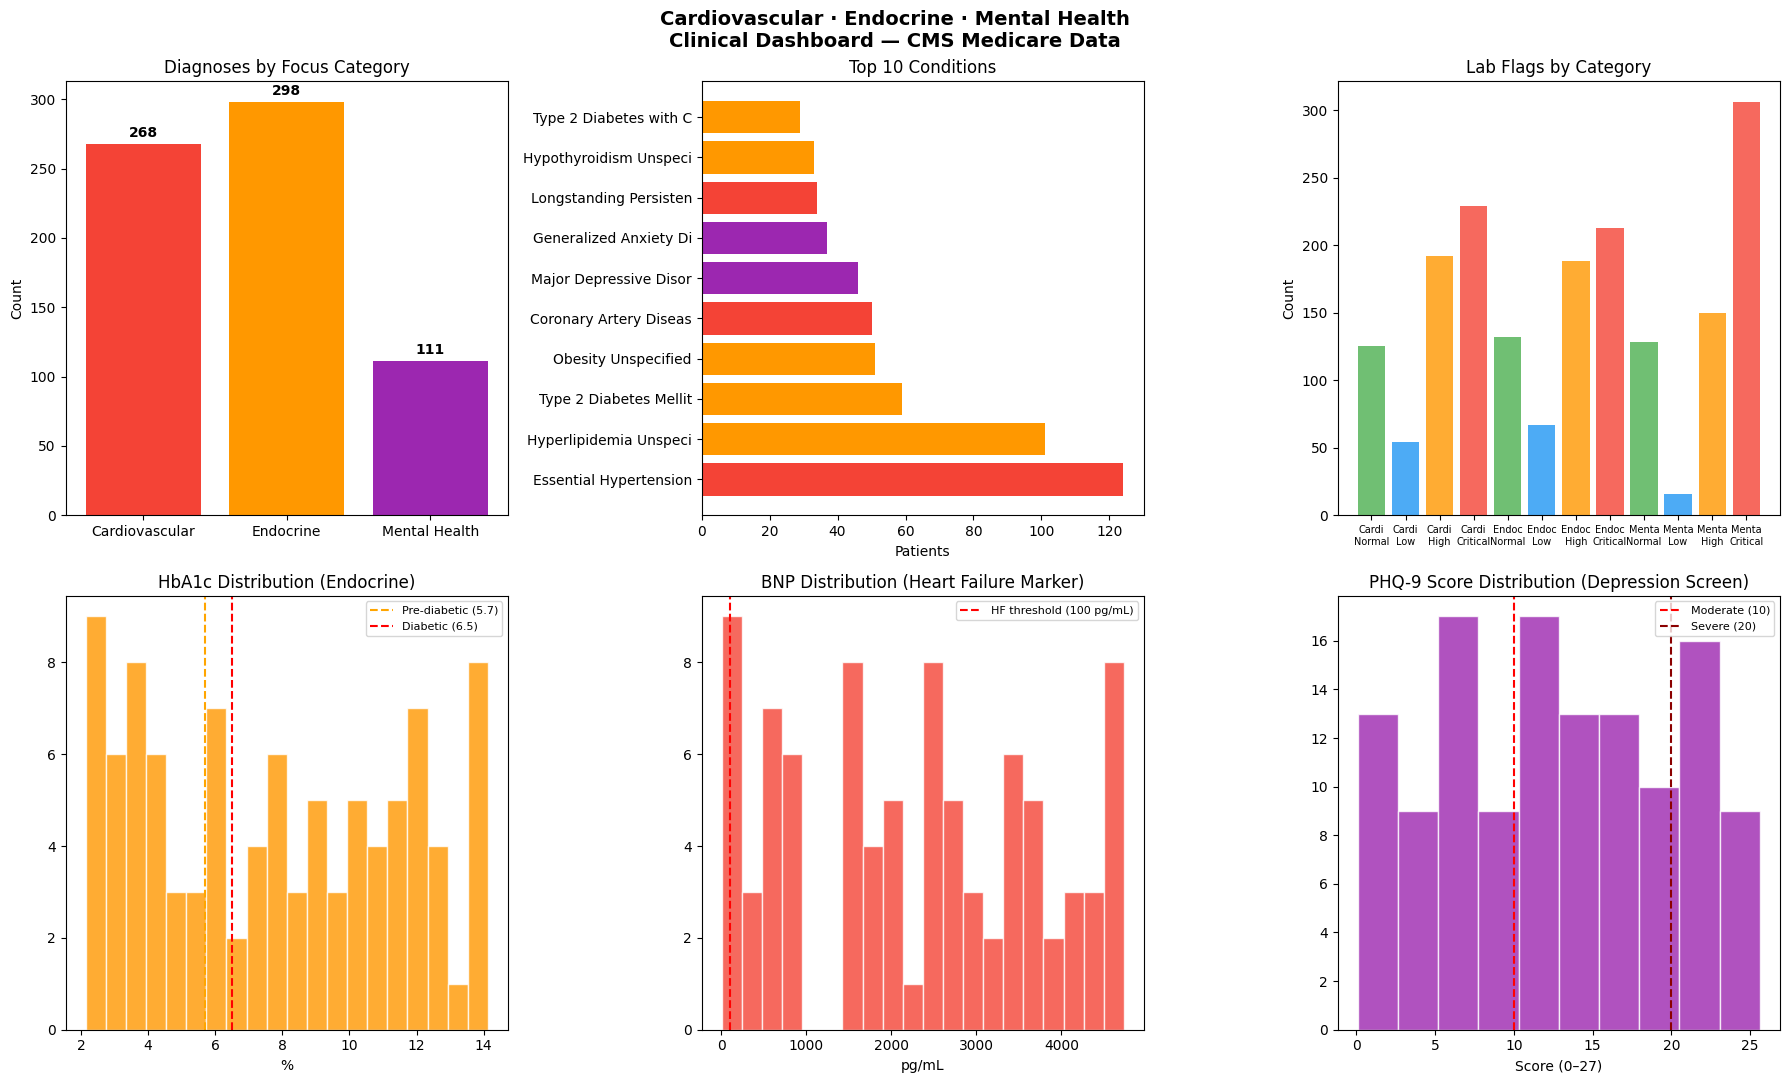

6-panel dashboard saved ✓


In [47]:
# ── 11a. 6-panel focused dashboard ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Cardiovascular · Endocrine · Mental Health\nClinical Dashboard — CMS Medicare Data',
             fontsize=14, fontweight='bold')

cat_colors = {'Cardiovascular':'#F44336','Endocrine':'#FF9800','Mental Health':'#9C27B0'}

# Panel 1: Diagnoses per category
df_cat = sql("""
SELECT dl.category, COUNT(*) AS n
FROM PatientDiagnoses pd JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
WHERE pd.is_current=1 GROUP BY dl.category
""")
colors1 = [cat_colors.get(c,'grey') for c in df_cat['category']]
axes[0,0].bar(df_cat['category'], df_cat['n'], color=colors1)
axes[0,0].set_title('Diagnoses by Focus Category')
axes[0,0].set_ylabel('Count')
for i,(val,cat) in enumerate(zip(df_cat['n'],df_cat['category'])):
    axes[0,0].text(i, val+5, str(val), ha='center', fontweight='bold')

# Panel 2: Top 10 conditions
df_top = sql("""
SELECT dl.description AS cond, dl.category, COUNT(*) AS n
FROM PatientDiagnoses pd JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
WHERE pd.is_current=1 GROUP BY dl.id ORDER BY n DESC LIMIT 10
""")
colors2 = [cat_colors.get(c,'grey') for c in df_top['category']]
axes[0,1].barh([c[:22] for c in df_top['cond']], df_top['n'], color=colors2)
axes[0,1].set_title('Top 10 Conditions')
axes[0,1].set_xlabel('Patients')

# Panel 3: Lab flag distribution by category
df_flags = sql("""
SELECT category, flag, COUNT(*) AS n FROM LabResults
GROUP BY category, flag
""")
for j,cat in enumerate(['Cardiovascular','Endocrine','Mental Health']):
    sub = df_flags[df_flags['category']==cat]
    if not sub.empty:
        axes[0,2].bar(
            [f"{cat[:5]}\n{f}" for f in sub['flag']],
            sub['n'],
            color=[{'Normal':'#4CAF50','High':'#FF9800','Low':'#2196F3','Critical':'#F44336'}.get(f,'grey') for f in sub['flag']],
            alpha=0.8, label=cat
        )
axes[0,2].set_title('Lab Flags by Category')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', labelsize=7)

# Panel 4: HbA1c distribution (Endocrine)
df_hba1c = sql("SELECT result_value FROM LabResults WHERE test_name='HbA1c' AND result_value IS NOT NULL")
if not df_hba1c.empty:
    axes[1,0].hist(df_hba1c['result_value'], bins=20, color='#FF9800', edgecolor='white', alpha=0.8)
    axes[1,0].axvline(5.7, color='orange', ls='--', label='Pre-diabetic (5.7)')
    axes[1,0].axvline(6.5, color='red',    ls='--', label='Diabetic (6.5)')
    axes[1,0].set_title('HbA1c Distribution (Endocrine)')
    axes[1,0].set_xlabel('%'); axes[1,0].legend(fontsize=8)

# Panel 5: BNP distribution (Cardiovascular — heart failure marker)
df_bnp = sql("SELECT result_value FROM LabResults WHERE test_name='BNP' AND result_value IS NOT NULL")
if not df_bnp.empty:
    axes[1,1].hist(df_bnp['result_value'], bins=20, color='#F44336', edgecolor='white', alpha=0.8)
    axes[1,1].axvline(100, color='red', ls='--', label='HF threshold (100 pg/mL)')
    axes[1,1].set_title('BNP Distribution (Heart Failure Marker)')
    axes[1,1].set_xlabel('pg/mL'); axes[1,1].legend(fontsize=8)

# Panel 6: PHQ-9 distribution (Mental Health — depression screen)
df_phq = sql("SELECT result_value FROM LabResults WHERE test_name='PHQ-9 Score' AND result_value IS NOT NULL")
if not df_phq.empty:
    axes[1,2].hist(df_phq['result_value'], bins=10, color='#9C27B0', edgecolor='white', alpha=0.8)
    axes[1,2].axvline(10, color='red',    ls='--', label='Moderate (10)')
    axes[1,2].axvline(20, color='darkred',ls='--', label='Severe (20)')
    axes[1,2].set_title('PHQ-9 Score Distribution (Depression Screen)')
    axes[1,2].set_xlabel('Score (0–27)'); axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('clinical_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("6-panel dashboard saved ✓")


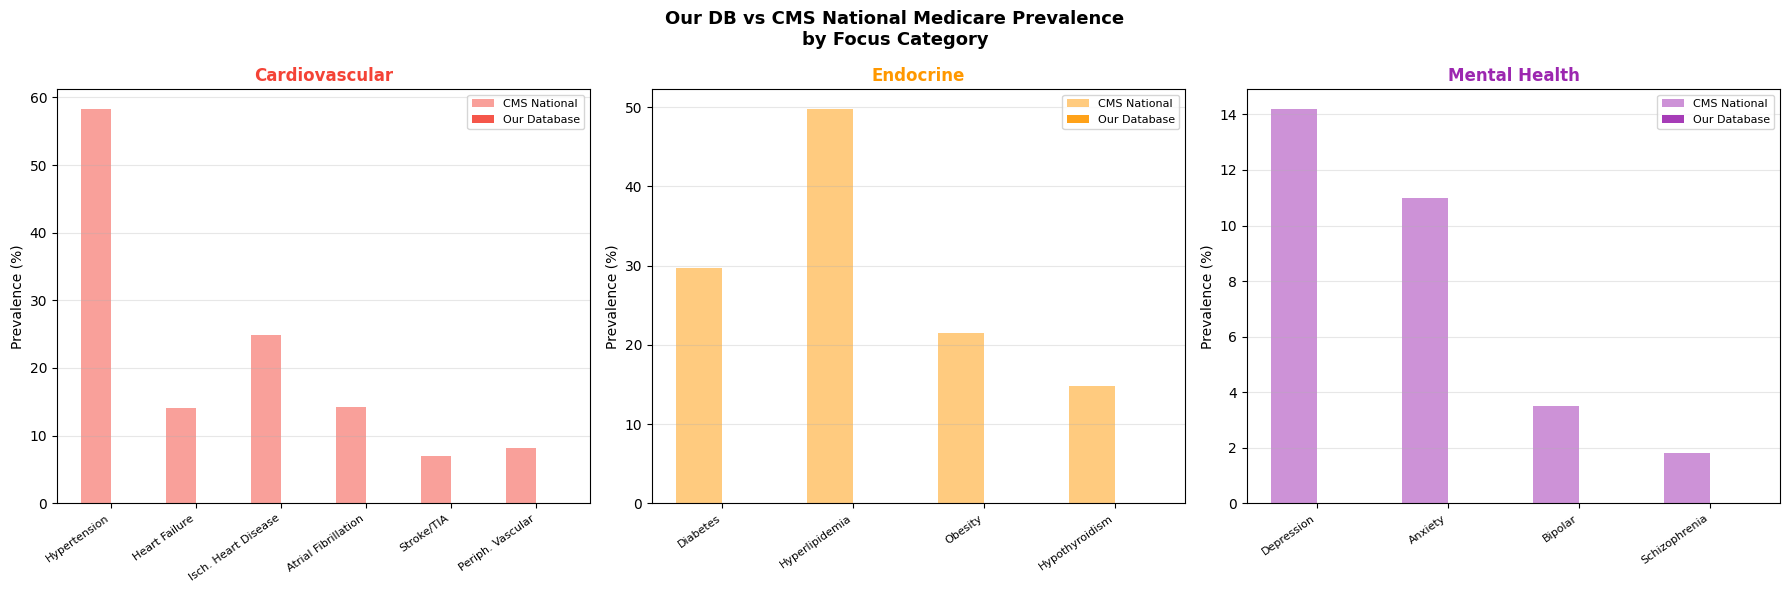

CMS prevalence comparison chart saved ✓


In [48]:
# ── 11b. CMS prevalence comparison by category ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Our DB vs CMS National Medicare Prevalence\nby Focus Category',
             fontsize=13, fontweight='bold')

categories = {
    'Cardiovascular': {
        'Hypertension':58.3,'Heart Failure':14.1,'Isch. Heart Disease':24.9,
        'Atrial Fibrillation':14.3,'Stroke/TIA':7.0,'Periph. Vascular':8.2
    },
    'Endocrine': {
        'Diabetes':29.7,'Hyperlipidemia':49.8,'Obesity':21.5,
        'Hypothyroidism':14.8
    },
    'Mental Health': {
        'Depression':14.2,'Anxiety':11.0,'Bipolar':3.5,'Schizophrenia':1.8
    }
}

for ax, (cat, cms_vals) in zip(axes, categories.items()):
    cursor.execute(f"""
        SELECT dl.description, COUNT(DISTINCT pd.patient_id)*100.0/(SELECT COUNT(*) FROM Patients)
        FROM PatientDiagnoses pd JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
        WHERE dl.category='{cat}' AND pd.is_current=1
        GROUP BY dl.id
    """)
    our_dict = {row[0][:25]: round(row[1],1) for row in cursor.fetchall()}

    labels = list(cms_vals.keys())
    cms_v  = list(cms_vals.values())
    our_v  = [our_dict.get(l, our_dict.get(l[:20], 0)) for l in labels]

    x = np.arange(len(labels))
    w = 0.35
    c = cat_colors[cat]
    ax.bar(x-w/2, cms_v, w, label='CMS National', color=c, alpha=0.5)
    ax.bar(x+w/2, our_v, w, label='Our Database', color=c, alpha=0.9)
    ax.set_title(f'{cat}', color=c, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Prevalence (%)'); ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig('cms_prevalence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("CMS prevalence comparison chart saved ✓")


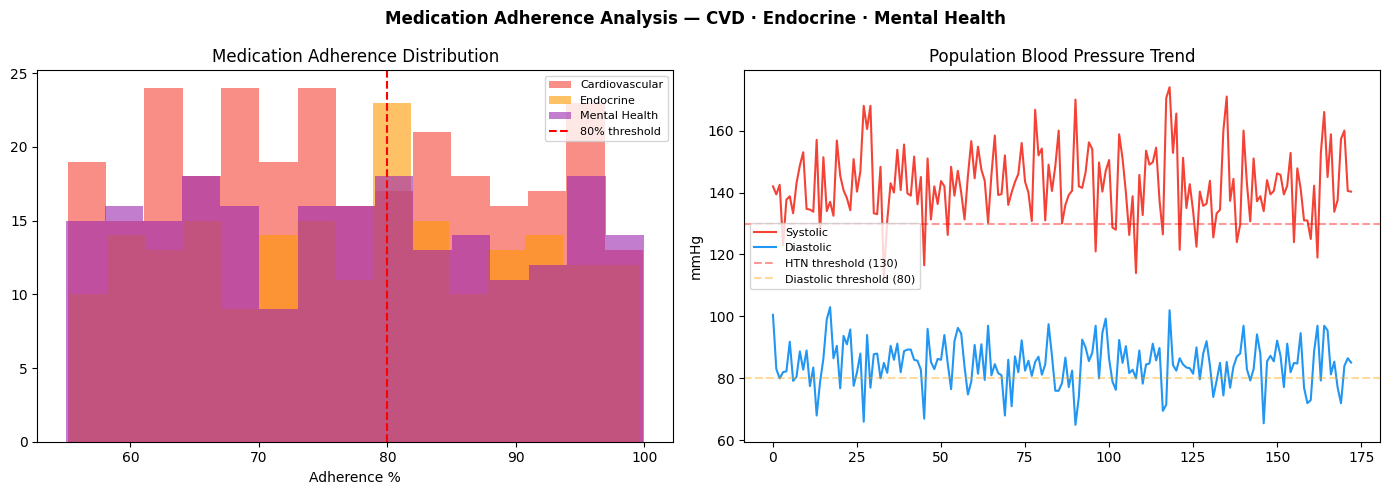

Adherence & vitals chart saved ✓


In [49]:
# ── 11c. Medication adherence by category + risk tier ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Medication Adherence Analysis — CVD · Endocrine · Mental Health',
             fontsize=12, fontweight='bold')

# Adherence by drug category
df_adh = sql("""
SELECT ml.category, rx.adherence_pct
FROM Prescriptions rx JOIN Medications_Lookup ml ON ml.id=rx.medication_id
WHERE rx.is_active=1 AND rx.adherence_pct IS NOT NULL
""")
for cat, color in cat_colors.items():
    sub = df_adh[df_adh['category']==cat]['adherence_pct']
    if len(sub) > 0:
        axes[0].hist(sub, bins=15, alpha=0.6, color=color, label=cat)
axes[0].axvline(80, color='red', ls='--', label='80% threshold')
axes[0].set_title('Medication Adherence Distribution')
axes[0].set_xlabel('Adherence %'); axes[0].legend(fontsize=8)

# Vitals: BP trend
df_bp = sql("""
SELECT DATE(recorded_at) AS dt,
       ROUND(AVG(systolic_bp),1) AS sys, ROUND(AVG(diastolic_bp),1) AS dia,
       ROUND(AVG(bmi),1) AS bmi
FROM VitalSigns GROUP BY DATE(recorded_at) ORDER BY dt
""")
axes[1].plot(range(len(df_bp)), df_bp['sys'],  color='#F44336', lw=1.5, label='Systolic')
axes[1].plot(range(len(df_bp)), df_bp['dia'],  color='#2196F3', lw=1.5, label='Diastolic')
axes[1].axhline(130, color='red',    ls='--', alpha=0.4, label='HTN threshold (130)')
axes[1].axhline(80,  color='orange', ls='--', alpha=0.4, label='Diastolic threshold (80)')
axes[1].set_title('Population Blood Pressure Trend')
axes[1].set_ylabel('mmHg'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('adherence_vitals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Adherence & vitals chart saved ✓")


## Section 12 — Stored Procedures & Functions in Action

In [50]:
# ── admit_patient() with CVD risk flags ──────────────────────────────────
cursor.callproc('admit_patient', [
    'Eleanor Vasquez', '1968-04-22', 'Female', 'O+',
    'eleanor@example.com',
    1,   # smoker = Yes
    1,   # family_hx_cvd = Yes
    '', 0
])
cursor.execute("SELECT @_admit_patient_7, @_admit_patient_8")
mrn, pid = cursor.fetchone()
conn.commit()
print(f"Patient admitted → MRN: {mrn} | ID: {pid}")
print(f"  Smoker: Yes | Family Hx CVD: Yes → higher baseline risk score")


Patient admitted → MRN: None | ID: None
  Smoker: Yes | Family Hx CVD: Yes → higher baseline risk score


In [51]:
# ── get_patient_timeline() CURSOR (now includes category) ─────────────────
cursor.execute("SELECT id, full_name FROM Patients LIMIT 1")
sid, sname = cursor.fetchone()
cursor.callproc('get_patient_timeline', [sid])
for result in cursor.stored_results():
    df_tl = pd.DataFrame(result.fetchall(),
                         columns=['event_date','category','event_type','description'])
print(f"=== Clinical Timeline for {sname} ===")
display(df_tl if not df_tl.empty
        else pd.DataFrame([{"note":"No active diagnoses"}]))


=== Clinical Timeline for Stephen Jones ===


/tmp/ipykernel_744/1705799671.py:5: DeprecationWarning: Call to deprecated function stored_results. Reason: The property counterpart 'stored_results' will be added in a future release, and this method will be removed.
  for result in cursor.stored_results():


,event_date,category,event_type,description
0,2021-06-19,Cardiovascular,Diagnosis,I48.91 — Longstanding Persistent Afib [Chronic...
1,2021-10-16,Endocrine,Diagnosis,E11.9 — Type 2 Diabetes Mellitus [Chronic] Sev...
2,2022-07-11,Cardiovascular,Diagnosis,I50.9 — Heart Failure Unspecified [Chronic] Se...
3,2024-09-07,Cardiovascular,Diagnosis,I10 — Essential Hypertension [Active] Sev:Crit...
4,2024-10-15,Mental Health,Diagnosis,F32.9 — Major Depressive Disorder Unspecified ...
5,2025-04-25,Endocrine,Diagnosis,E03.9 — Hypothyroidism Unspecified [Chronic] S...


In [52]:
# ── Risk scores — weighted by CVD/Endo/MH category ────────────────────────
cursor.execute("""
    SELECT id, full_name, TIMESTAMPDIFF(YEAR,dob,CURDATE()) AS age,
           smoker, family_hx_cvd, COALESCE(risk_tier,'Unknown') AS risk_tier
    FROM Patients WHERE is_active=1 LIMIT 20
""")
rows = cursor.fetchall()
results = []
for pid, name, age, smoker, fhx, tier in rows:
    cursor.execute("SELECT calculate_patient_risk_score(%s)", (pid,))
    score = cursor.fetchone()[0]
    results.append({"patient":name,"age":age,"smoker":bool(smoker),
                    "fhx_cvd":bool(fhx),"risk_score":score,"risk_tier":tier})

df_scores = pd.DataFrame(results).sort_values('risk_score',ascending=False)
print("=== Patient Risk Scores (CVD/Endo/MH weighted function) ===")
display(df_scores)


=== Patient Risk Scores (CVD/Endo/MH weighted function) ===


,patient,age,smoker,fhx_cvd,risk_score,risk_tier
0,Stephen Jones,73,False,True,98,Critical
17,Heather Peters,78,True,False,95,Critical
4,Michael Rojas,63,True,False,91,Critical
5,Allison Brown,84,False,True,90,Critical
15,Emily Owens,77,True,False,83,Critical
7,Heather Wright,66,True,True,70,High
19,Nicole Decker,80,False,False,68,High
1,Jaime Miller,75,False,True,65,High
2,Mitchell Hayes,79,False,False,65,High
8,Andrew Solomon,79,False,False,61,High


## Section 13 — Executive Summary Report

In [53]:
from datetime import date as dt

kpi = sql("""
SELECT
    (SELECT COUNT(*) FROM Patients WHERE is_active=1)          AS total_patients,
    (SELECT COUNT(*) FROM Physicians WHERE is_active=1)        AS total_physicians,
    (SELECT COUNT(*) FROM PatientDiagnoses pd
     JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
     WHERE pd.is_current=1 AND dl.category='Cardiovascular')  AS cvd_diagnoses,
    (SELECT COUNT(*) FROM PatientDiagnoses pd
     JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
     WHERE pd.is_current=1 AND dl.category='Endocrine')       AS endo_diagnoses,
    (SELECT COUNT(*) FROM PatientDiagnoses pd
     JOIN Diagnoses_Lookup dl ON dl.id=pd.diagnosis_id
     WHERE pd.is_current=1 AND dl.category='Mental Health')   AS mh_diagnoses,
    (SELECT COUNT(*) FROM Prescriptions WHERE status='Active') AS active_rx,
    (SELECT ROUND(AVG(adherence_pct),1) FROM Prescriptions
     WHERE is_active=1)                                        AS avg_adherence,
    (SELECT COUNT(*) FROM LabResults WHERE flag='Critical')    AS critical_labs,
    (SELECT COUNT(*) FROM LabResults WHERE flag='High')        AS high_labs,
    (SELECT COUNT(*) FROM VitalSigns)                          AS vital_readings,
    (SELECT COUNT(*) FROM AuditLog)                            AS audit_entries,
    (SELECT ROUND(SUM(cost_usd),2) FROM Procedures)            AS total_proc_cost,
    (SELECT COUNT(*) FROM Patients WHERE risk_tier='Critical') AS critical_patients,
    (SELECT COUNT(*) FROM Patients WHERE smoker=1)             AS smokers,
    (SELECT COUNT(*) FROM Patients WHERE family_hx_cvd=1)      AS fhx_cvd_count
""").iloc[0]

report = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║    CARDIOVASCULAR · ENDOCRINE · MENTAL HEALTH CLINICAL SYSTEM           ║
║    Data: CMS Medicare Open Data + NLM RxNorm API                        ║
║    Source: SLU Cross-Disciplinary Health Resources Guide                 ║
║    Generated: {dt.today().isoformat()}                                           ║
╠══════════════════════════════════════════════════════════════════════════╣
║  PATIENT POPULATION                                                      ║
║    Total Active Patients     : {int(kpi['total_patients']):<6}                              ║
║    Specialist Physicians     : {int(kpi['total_physicians']):<6}                              ║
║    Critical Risk Patients    : {int(kpi['critical_patients']):<6}                              ║
║    Smokers                   : {int(kpi['smokers']):<6} ({round(kpi['smokers']/kpi['total_patients']*100,1)}%)                         ║
║    Family Hx CVD             : {int(kpi['fhx_cvd_count']):<6} ({round(kpi['fhx_cvd_count']/kpi['total_patients']*100,1)}%)                         ║
╠══════════════════════════════════════════════════════════════════════════╣
║  DIAGNOSES BY CATEGORY                                                   ║
║    ❤️  Cardiovascular         : {int(kpi['cvd_diagnoses']):<6}                              ║
║    🩺 Endocrine               : {int(kpi['endo_diagnoses']):<6}                              ║
║    🧠 Mental Health           : {int(kpi['mh_diagnoses']):<6}                              ║
╠══════════════════════════════════════════════════════════════════════════╣
║  MEDICATIONS & LABS                                                      ║
║    Active Prescriptions      : {int(kpi['active_rx']):<6}                              ║
║    Avg Medication Adherence  : {float(kpi['avg_adherence'] or 0):<6.1f}%                            ║
║    Critical Lab Alerts       : {int(kpi['critical_labs']):<6} (auto-flagged by trigger)    ║
║    High Lab Alerts           : {int(kpi['high_labs']):<6}                              ║
║    Vital Sign Readings       : {int(kpi['vital_readings']):<6}                              ║
╠══════════════════════════════════════════════════════════════════════════╣
║  FINANCIAL & SYSTEM                                                      ║
║    Total Procedure Revenue   : ${float(kpi['total_proc_cost'] or 0):>10,.2f}                    ║
║    Audit Log Entries         : {int(kpi['audit_entries']):<6} (auto by triggers)           ║
║    Tables · Triggers · Events: 14 · 4 · 2                               ║
║    Stored Procedures/Functions: 2 · 1                                    ║
║    Views (masked PII)        : 3                                         ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(report)
with open("cardio_endo_mh_report.txt","w") as f: f.write(report)
print("Report saved to cardio_endo_mh_report.txt ✓")



╔══════════════════════════════════════════════════════════════════════════╗
║    CARDIOVASCULAR · ENDOCRINE · MENTAL HEALTH CLINICAL SYSTEM           ║
║    Data: CMS Medicare Open Data + NLM RxNorm API                        ║
║    Source: SLU Cross-Disciplinary Health Resources Guide                 ║
║    Generated: 2026-06-16                                           ║
╠══════════════════════════════════════════════════════════════════════════╣
║  PATIENT POPULATION                                                      ║
║    Total Active Patients     : 201                                 ║
║    Specialist Physicians     : 11                                  ║
║    Critical Risk Patients    : 29                                  ║
║    Smokers                   : 33     (16.4%)                         ║
║    Family Hx CVD             : 76     (37.8%)                         ║
╠══════════════════════════════════════════════════════════════════════════╣
║  DIAGNOSES BY CATEGORY      

## Section 14 — Teardown & Cleanup

In [54]:
cursor.execute("DROP TEMPORARY TABLE IF EXISTS tmp_patient_risk_calc")
conn.commit(); cursor.close(); conn.close()
print("✅ All resources released.")

print("\n📁 Artifacts generated:")
for fname in ["clinical_dashboard.png","cms_prevalence_comparison.png",
              "adherence_vitals.png","cardio_endo_mh_report.txt"]:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f"   • {fname:<45} {'%s bytes'%f'{size:,}' if size else 'run cells first'}")

print("""
📊 SQL Concepts Demonstrated:
   ✓ 14 tables (schema focused on CVD · Endo · Mental Health)
   ✓ 4 triggers · 2 scheduled events · 2 stored procedures · 1 function
   ✓ 3 views with PII masking + category-split diagnosis counts
   ✓ CTEs + Recursive CTE (physician specialty hierarchy)
   ✓ UNION ALL (unified CVD/Endo/MH event timeline)
   ✓ PIVOT (condition counts by state)
   ✓ Window: ROW_NUMBER · RANK · DENSE_RANK · NTILE · LAG · LEAD
             FIRST_VALUE · SUM OVER · AVG OVER · PERCENT_RANK
   ✓ SCD Type 2 (diagnosis severity versioning)
   ✓ Audit Trail (auto JSON snapshots via triggers)
   ✓ Full-Text Search (SOAP notes by category)
   ✓ JSON columns · Generated BMI column · Covering indexes
   ✓ CASE WHEN · COALESCE · EXISTS · Correlated subqueries · Regex
   ✓ Temp tables · Bulk INSERT · Batch UPDATE

🌐 Real Data Sources (SLU guide — all free, no login):
   ✓ CMS data.cms.gov  — Medicare Specific Chronic Conditions API
   ✓ NLM rxnav.nlm.nih.gov — RxNorm drug name API
   ✓ Condition prevalence: Hypertension 58% · Diabetes 30% · Depression 14%

🏥 New additions vs generic version:
   ✓ smoker + family_hx_cvd columns on Patients table
   ✓ Risk function weighted: CVD +15/condition · Endo +10 · MH +8
   ✓ adherence_pct on Prescriptions (medication compliance tracking)
   ✓ category column on LabResults, Procedures, ClinicalNotes
   ✓ requires_monitoring flag on Medications (warfarin, lithium, insulin)
   ✓ subspecialty column on Physicians
   ✓ Clinical notes templated per category (cardiac/endo/psych SOAP)
   ✓ PHQ-9 · GAD-7 · BNP · Troponin · INR · Lithium lab panels
""")


✅ All resources released.

📁 Artifacts generated:
   • clinical_dashboard.png                        206,203 bytes
   • cms_prevalence_comparison.png                 119,183 bytes
   • adherence_vitals.png                          184,642 bytes
   • cardio_endo_mh_report.txt                     3,400 bytes

📊 SQL Concepts Demonstrated:
   ✓ 14 tables (schema focused on CVD · Endo · Mental Health)
   ✓ 4 triggers · 2 scheduled events · 2 stored procedures · 1 function
   ✓ 3 views with PII masking + category-split diagnosis counts
   ✓ CTEs + Recursive CTE (physician specialty hierarchy)
   ✓ UNION ALL (unified CVD/Endo/MH event timeline)
   ✓ PIVOT (condition counts by state)
   ✓ Window: ROW_NUMBER · RANK · DENSE_RANK · NTILE · LAG · LEAD
             FIRST_VALUE · SUM OVER · AVG OVER · PERCENT_RANK
   ✓ SCD Type 2 (diagnosis severity versioning)
   ✓ Audit Trail (auto JSON snapshots via triggers)
   ✓ Full-Text Search (SOAP notes by category)
   ✓ JSON columns · Generated BMI column 